In [290]:
import pandas as pd
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt
import pickle as pck
import joblib as jlb
from scipy.stats import norm
from random import sample
from sklearn.ensemble import IsolationForest 
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.feature_selection import f_classif, SelectKBest
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification
from sklearn.linear_model    import LogisticRegression
from sklearn.metrics         import roc_auc_score, roc_curve, auc
from sklearn.preprocessing   import MinMaxScaler, StandardScaler
from sklearn.model_selection import cross_val_score
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from imblearn.over_sampling import SMOTE

# Lectura de datos

In [291]:
df = pd.read_csv('datos.csv')

# Analisis de Datos

In [292]:
df.shape

(284807, 36)

In [293]:
df.head()

,transaction_id,timestamp,amount,variable_01,variable_02,variable_03,variable_04,variable_05,variable_06,variable_07,variable_08,variable_09,variable_10,variable_11,variable_12,variable_13,variable_14,variable_15,variable_16,variable_17,variable_18,variable_19,variable_20,variable_21,variable_22,variable_23,variable_24,variable_25,variable_26,variable_27,variable_28,variable_29,variable_30,variable_31,variable_32,is_fraud
0,99899e9e02c4b41fc442744220e6fa12f8d36b26f70027...,155270.0,12.00,-0.071330,-0.032900,0.109989,0.339889,-0.626131,-0.116853,1.220826,0.394041,0.051705,0.700084,-1.185263,-0.183050,1.051029,0.267423,-0.220569,1.358207,-0.321922,-1.121246,0.852400,-0.635935,-0.445327,-0.251412,-0.989219,-0.168169,-1.054944,-1.603176,-0.616640,2.283078,0.373964,1.576543,-0.941557,-0.105280,0
1,d678605da2ed45d14c95228b2e6a0daa1c635c7c5d3f7c...,46054.0,208.89,0.057858,0.003669,0.076745,0.392782,0.458835,-0.279094,0.435257,0.230350,0.292049,0.624199,0.327219,-0.032708,-0.372193,1.440826,-0.049183,-0.595081,0.376050,-0.518996,-1.245331,2.034140,-0.073293,-0.439827,-0.863551,-1.606923,-1.100937,0.597263,-1.228029,0.875399,0.260934,-0.558290,0.763729,0.011740,0
2,5f178ebbecf592c3ea98b5b26ff3547f8a40e88aa428d5...,167866.0,1.00,-0.002449,0.019520,-0.038565,0.400659,-1.214922,-0.177434,0.303247,0.030461,-0.112687,-0.307426,1.595186,1.385215,1.068869,1.133506,-2.619782,0.277352,-0.512077,-0.713025,-1.201109,0.561721,-0.351699,0.362076,-1.215083,1.044934,0.533274,-2.802382,0.570268,2.121604,-0.131120,1.603304,-0.032323,0.062465,0
3,455543a8012484e430efd18300186319bf8da376811333...,163539.0,15.00,-0.039202,-0.031762,-0.328682,-0.045094,0.606368,0.204822,0.014322,0.013439,0.016800,0.861519,-0.891606,1.139910,1.179129,-0.795164,-1.056983,-0.142009,-0.026496,1.408220,0.446607,-0.791305,-0.159512,-0.300838,-0.787018,0.020468,-0.853713,-1.915028,-0.478400,2.161957,-1.117518,1.768693,-0.517470,-0.101639,0
4,d8637ef4c5c833fee92149b5b8ef2fad601196be9b7c89...,153872.0,0.01,-0.058206,-0.051926,0.653525,-0.387901,0.806301,0.227390,0.676840,0.209482,-0.206405,0.367224,0.721541,-0.713888,0.496167,0.629590,0.325217,-0.947716,0.513088,0.854643,-0.175665,1.449330,0.141885,-0.854064,-0.347373,-0.750013,-0.914675,-0.595874,-0.705751,2.026529,2.221984,0.744251,-0.768323,-0.166163,0


In [294]:
df.isnull().sum() # Podemos ver que aparentemente no hay valores nulos

transaction_id    0
timestamp         0
amount            0
variable_01       0
variable_02       0
variable_03       0
variable_04       0
variable_05       0
variable_06       0
variable_07       0
variable_08       0
variable_09       0
variable_10       0
variable_11       0
variable_12       0
variable_13       0
variable_14       0
variable_15       0
variable_16       0
variable_17       0
variable_18       0
variable_19       0
variable_20       0
variable_21       0
variable_22       0
variable_23       0
variable_24       0
variable_25       0
variable_26       0
variable_27       0
variable_28       0
variable_29       0
variable_30       0
variable_31       0
variable_32       0
is_fraud          0
dtype: int64

In [295]:
porcent = (df['is_fraud'].value_counts())/(len(df))*100 # El datatset esta desbalanceado por lo que procedemos a hacer 
porcent                                                 # Oversampling y subsampling

is_fraud
0    99.827251
1     0.172749
Name: count, dtype: float64

In [296]:
df.info() # Todos los datos tienen valores numericos a excepcion de transaction_id

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 36 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   transaction_id  284807 non-null  object 
 1   timestamp       284807 non-null  float64
 2   amount          284807 non-null  float64
 3   variable_01     284807 non-null  float64
 4   variable_02     284807 non-null  float64
 5   variable_03     284807 non-null  float64
 6   variable_04     284807 non-null  float64
 7   variable_05     284807 non-null  float64
 8   variable_06     284807 non-null  float64
 9   variable_07     284807 non-null  float64
 10  variable_08     284807 non-null  float64
 11  variable_09     284807 non-null  float64
 12  variable_10     284807 non-null  float64
 13  variable_11     284807 non-null  float64
 14  variable_12     284807 non-null  float64
 15  variable_13     284807 non-null  float64
 16  variable_14     284807 non-null  float64
 17  variable_1

In [297]:
pd.set_option('display.max_column',None)
df.describe(percentiles=[0.01,.25,.50,.75,.99]) # Buscamos si hay outliers, al parecer hay
                                                # un valor muy grande en amount

,timestamp,amount,variable_01,variable_02,variable_03,variable_04,variable_05,variable_06,variable_07,variable_08,variable_09,variable_10,variable_11,variable_12,variable_13,variable_14,variable_15,variable_16,variable_17,variable_18,variable_19,variable_20,variable_21,variable_22,variable_23,variable_24,variable_25,variable_26,variable_27,variable_28,variable_29,variable_30,variable_31,variable_32,is_fraud
count,284807.000000,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000
mean,94813.859575,88.349619,-1.247286e-16,-3.675372e-16,1.687909e-15,5.135217e-16,4.471943e-15,2.633534e-16,-3.505225e-16,1.626624e-16,6.452607e-16,1.037596e-15,9.708849e-16,-3.755206e-16,1.434136e-15,4.887206e-15,1.210587e-15,8.243889e-16,-1.247361e-15,1.699373e-15,2.236932e-15,-2.411096e-15,1.147618e-16,-5.633807e-16,1.497617e-15,1.007309e-15,2.095151e-15,-1.401416e-15,3.384974e-16,1.177057e-15,5.730855e-15,2.153892e-15,-1.611056e-15,-1.168774e-15,0.001727
std,47488.145955,250.120109,3.300833e-01,4.036325e-01,4.822270e-01,5.212781e-01,6.056471e-01,6.244603e-01,7.257016e-01,7.345240e-01,7.709250e-01,8.140405e-01,8.381762e-01,8.493371e-01,8.762529e-01,9.153160e-01,9.585956e-01,9.952742e-01,9.992014e-01,1.020713e+00,1.088850e+00,1.098632e+00,1.194353e+00,1.237094e+00,1.332271e+00,1.380247e+00,1.415869e+00,1.516255e+00,1.651309e+00,1.958696e+00,1.639572e+00,1.314379e+00,4.357099e+00,1.291624e+00,0.041527
min,0.000000,0.000000,-1.543008e+01,-2.256568e+01,-2.604551e+00,-1.029540e+01,-2.836627e+00,-4.480774e+01,-1.093314e+01,-3.483038e+01,-5.449772e+01,-7.213527e+00,-9.498746e+00,-2.516280e+01,-1.412985e+01,-4.498945e+00,-1.921433e+01,-5.791881e+00,-1.868371e+01,-4.797473e+00,-2.458826e+01,-1.343407e+01,-7.321672e+01,-4.355724e+01,-2.616051e+01,-1.137433e+02,-5.683171e+00,-4.832559e+01,-7.271573e+01,-5.640751e+01,-8.855472e+00,-2.119478e+01,-2.036771e+02,-7.221017e+01,0.000000
1%,2422.000000,0.120000,-8.762654e-01,-1.247746e+00,-1.009384e+00,-1.420859e+00,-1.657308e+00,-1.193417e+00,-1.654625e+00,-1.469679e+00,-1.568406e+00,-2.075516e+00,-2.147067e+00,-1.349962e+00,-2.381823e+00,-2.383923e+00,-2.799763e+00,-2.283101e+00,-3.063938e+00,-2.093086e+00,-2.092670e+00,-2.455288e+00,-4.033899e+00,-3.012847e+00,-2.124023e+00,-3.060396e+00,-3.122987e+00,-3.978377e+00,-4.960300e+00,-6.563199e+00,-3.431905e+00,-3.572735e+00,-1.156670e+01,-3.992787e+00,0.000000
25%,54201.500000,5.600000,-5.295979e-02,-7.083953e-02,-3.269839e-01,-3.171451e-01,-3.545861e-01,-1.618463e-01,-5.423504e-01,-2.283949e-01,-2.117214e-01,-4.562989e-01,-4.988498e-01,-4.837483e-01,-4.680368e-01,-5.828843e-01,-4.255740e-01,-6.485393e-01,-4.055715e-01,-7.624942e-01,-5.354257e-01,-6.430976e-01,-2.086297e-01,-5.540759e-01,-7.682956e-01,-6.915971e-01,-8.486401e-01,-8.903648e-01,-5.985499e-01,-9.203734e-01,-1.111745e+00,-7.020552e-01,-6.990693e-01,-2.266865e-01,0.000000
50%,84692.000000,22.000000,1.124383e-02,1.342146e-03,-5.213911e-02,1.659350e-02,4.097606e-02,-1.119293e-02,6.781943e-03,-2.945017e-02,-6.248109e-02,3.734823e-03,-3.636312e-03,-6.567575e-02,6.641332e-02,4.807155e-02,5.060132e-02,-1.356806e-02,1.400326e-01,-3.275735e-02,-9.291738e-02,-5.142873e-02,2.235804e-02,4.010308e-02,-2.741871e-01,-5.433583e-02,-1.984653e-02,1.798463e-01,6.548556e-02,1.810880e-02,-1.772730e-01,9.961998e-02,1.484186e-01,4.294867e-03,0.000000
75%,139320.500000,77.165000,7.827995e-02,9.104512e-02,2.409522e-01,3.507156e-01,4.395266e-01,1.476421e-01,5.285536e-01,1.863772e-01,1.330408e-01,4.589494e-01,5.008067e-01,3.996750e-01,5.232963e-01,6.488208e-01,4.931498e-01,6.625050e-01,6.182380e-01,7.395934e-01,4.539234e-01,5.971390e-01,3.273459e-01

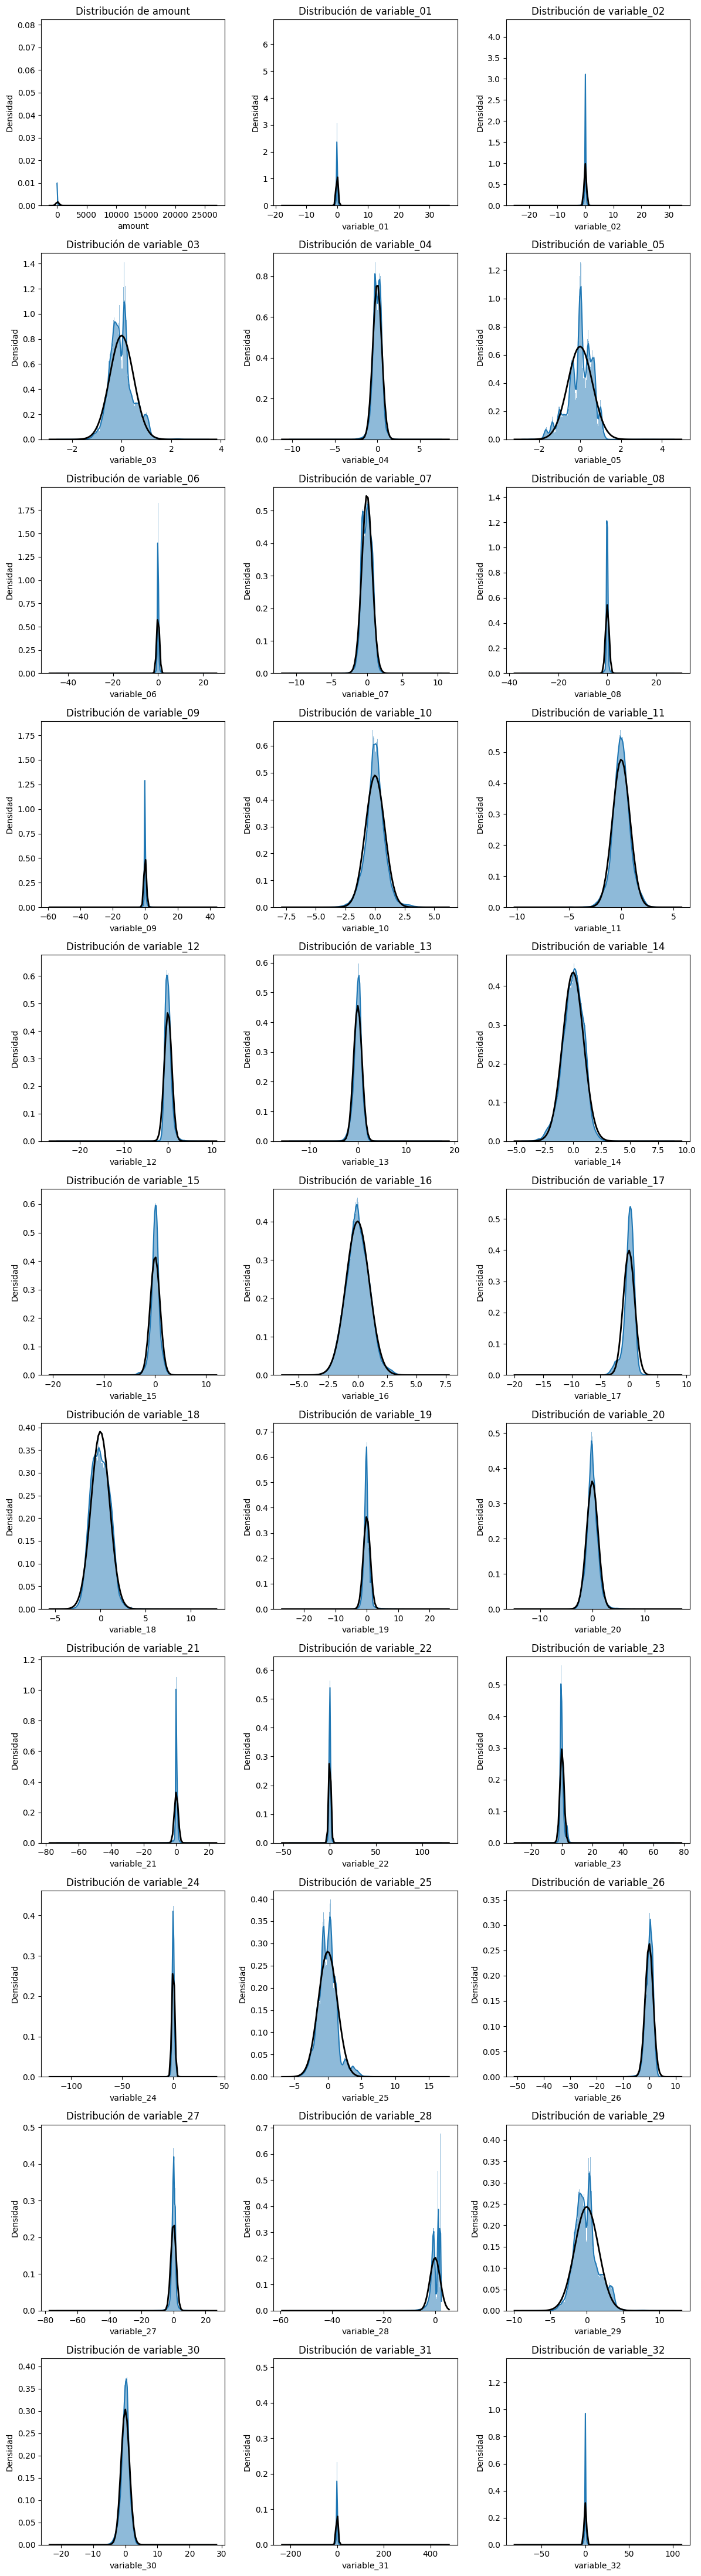

In [298]:
# Solo tenemos columnas continuas por lo que simplemente vamos a separar el transaction id, timestamp y la variable objetivo
list_descart = ['transaction_id','is_fraud','timestamp']
df_column_cont = df.drop(columns = list_descart)
list_column = df_column_cont.columns

num_var = len(list_column)
cols = 3
rows = (num_var // cols) + (num_var % cols > 0)
plt.figure(figsize=(cols * 4, rows * 4))

for i, var in enumerate(list_column, 1):
    plt.subplot(rows, cols, i)  
    sns.histplot(df[var], kde=True, stat="density", linewidth=0)
    
    # Ajustar la distribución normal
    mu, std = norm.fit(df[var].dropna())  # Eliminar NaN para el ajuste a pesar de que comprobamos que no hay anteriormente
    xmin, xmax = plt.xlim()
    x = np.linspace(xmin, xmax, 100)
    p = norm.pdf(x, mu, std)
    plt.plot(x, p, 'k', linewidth=2)
    
    # Título y etiquetas
    plt.title(f'Distribución de {var}')
    plt.xlabel(var)
    plt.ylabel('Densidad')

plt.tight_layout()
plt.show() # Podemos ver que algunas graficas tienenen una escala en los ejes muy grande, esto puedes ser por los outliers


In [299]:
df_iso = df[list_column].copy()
iso_forest = IsolationForest(n_estimators = 100, contamination = 0.01 ,random_state = 42)
df_iso['outlier_score'] = iso_forest.fit_predict(df_iso)
df['outlier_score'] = df_iso['outlier_score']
df_sin_out = df[df['outlier_score'] == 1]
#df_sin_out = df.copy()

In [300]:
df_sin_out.describe(percentiles=[0.01,.25,.50,.75,.99])

,timestamp,amount,variable_01,variable_02,variable_03,variable_04,variable_05,variable_06,variable_07,variable_08,variable_09,variable_10,variable_11,variable_12,variable_13,variable_14,variable_15,variable_16,variable_17,variable_18,variable_19,variable_20,variable_21,variable_22,variable_23,variable_24,variable_25,variable_26,variable_27,variable_28,variable_29,variable_30,variable_31,variable_32,is_fraud,outlier_score
count,281958.000000,281958.000000,281958.000000,281958.000000,281958.000000,281958.000000,281958.000000,281958.000000,281958.000000,281958.000000,281958.000000,281958.000000,281958.000000,281958.000000,281958.000000,281958.000000,281958.000000,281958.000000,281958.000000,281958.000000,281958.000000,281958.000000,281958.000000,281958.000000,281958.000000,281958.000000,281958.000000,281958.000000,281958.000000,281958.000000,281958.000000,281958.000000,281958.000000,281958.000000,281958.000000,281958.0
mean,94836.038268,81.040958,0.001590,0.000529,0.000575,-0.001152,-0.000161,0.001651,0.002660,0.000915,0.001285,0.001057,0.004417,0.008276,0.001858,-0.003322,0.008470,-0.002773,0.004709,-0.007263,-0.007018,-0.009402,0.017264,0.009879,-0.003798,0.023465,-0.015139,0.045276,0.019487,0.090054,0.001954,0.002787,0.020994,0.001694,0.000823,1.0
std,47485.467316,179.335874,0.215231,0.309976,0.480856,0.506181,0.604198,0.438430,0.705563,0.578370,0.533575,0.805041,0.819939,0.726006,0.829439,0.910947,0.869338,0.992977,0.933560,0.994726,0.947272,1.049240,0.932586,0.953266,1.259740,1.174146,1.374856,1.368030,1.312322,1.646266,1.634911,1.244158,2.841049,0.991924,0.028673,0.0
min,0.000000,0.000000,-4.987659,-8.878665,-1.855355,-3.773884,-2.836627,-17.018295,-5.788277,-9.333276,-8.422574,-4.932733,-5.131549,-12.598419,-7.552342,-4.391307,-12.457999,-4.008640,-10.912819,-3.684586,-6.999907,-4.441942,-21.261116,-11.471554,-11.814344,-10.262641,-5.683171,-10.800586,-21.135261,-18.589909,-6.308208,-11.328513,-65.837096,-28.411728,0.000000,1.0
1%,2414.710000,0.120000,-0.754864,-1.094965,-1.004065,-1.382807,-1.656302,-1.034470,-1.598366,-1.301133,-1.258457,-2.052203,-2.103042,-1.308522,-2.331498,-2.382054,-2.601794,-2.279699,-3.009802,-2.075612,-1.999904,-2.416986,-3.282091,-2.455435,-2.009030,-2.551738,-3.110989,-3.472511,-4.268645,-5.122909,-3.413822,-3.497247,-9.964202,-3.503889,0.000000,1.0
25%,54240.250000,5.600000,-0.052197,-0.070136,-0.326291,-0.316199,-0.354145,-0.160570,-0.539084,-0.226447,-0.210131,-0.452135,-0.495894,-0.482229,-0.465651,-0.584198,-0.420817,-0.650210,-0.403174,-0.761855,-0.531684,-0.640561,-0.204898,-0.546634,-0.765558,-0.679363,-0.848065,-0.858419,-0.591549,-0.893598,-1.109389,-0.698476,-0.688998,-0.224437,0.000000,1.0
50%,84676.000000,21.970000,0.011309,0.001300,-0.051418,0.015509,0.040777,-0.011328,0.007735,-0.029256,-0.062573,0.005332,-0.002479,-0.066225,0.065051,0.045974,0.050795,-0.015947,0.139072,-0.035222,-0.093497,-0.052702,0.023357,0.041085,-0.274981,-0.049878,-0.023211,0.192193,0.064771,0.039457,-0.174822,0.097577,0.149280,0.004161,0.000000,1.0
75%,139337.750000,76.000000,0.077220,0.089303,0.240373,0.348337,0.438549,0.145712,0.527452,0.184558,0.130454,0.457547,0.499797,0.395691,0.518447,0.644871,0.489371,0.659669,0.614316,0.733746,0.444484,0.589347,0.325059,0.566320,0.389544,0.611927,0.730873,1.033836,0.795045,1.320957,0.817267,0.777671,1.019300,0.285770,0.000000,1.0
99%,170549.000000,920.561700,0.466101,0.773779,1.156576,1.160376,1.060816,1.340333,1.507440,1.644943,2.069353,2.221212,2.062354,2.215585,1.824843,1.898501,2.069441,2.503907,1.643768,2.213143,2.746507,2.781745,1.861185,2.375497,4.117339,3.318092,4.119543,2.728589,3.270206,2.237711,3.932358,2.737265,6.152537,2.476094,0.000000,1.0
max,172792.000000,3106.440000,5.678671,3.479621,3.517346,3.265186,4.022866,9.143317,3.893776,15.248762,6.535743,4.715142,4.243841,7.893393,3.660569,4.198583,6.441021,4.569009,4.113493,6.439053,12.076134,7.730701,8.051834,12.735925,9.274052,16.878967,8.005351,4.187811,9.349373,2.454930,11.958975,5.490854,74.958457,11

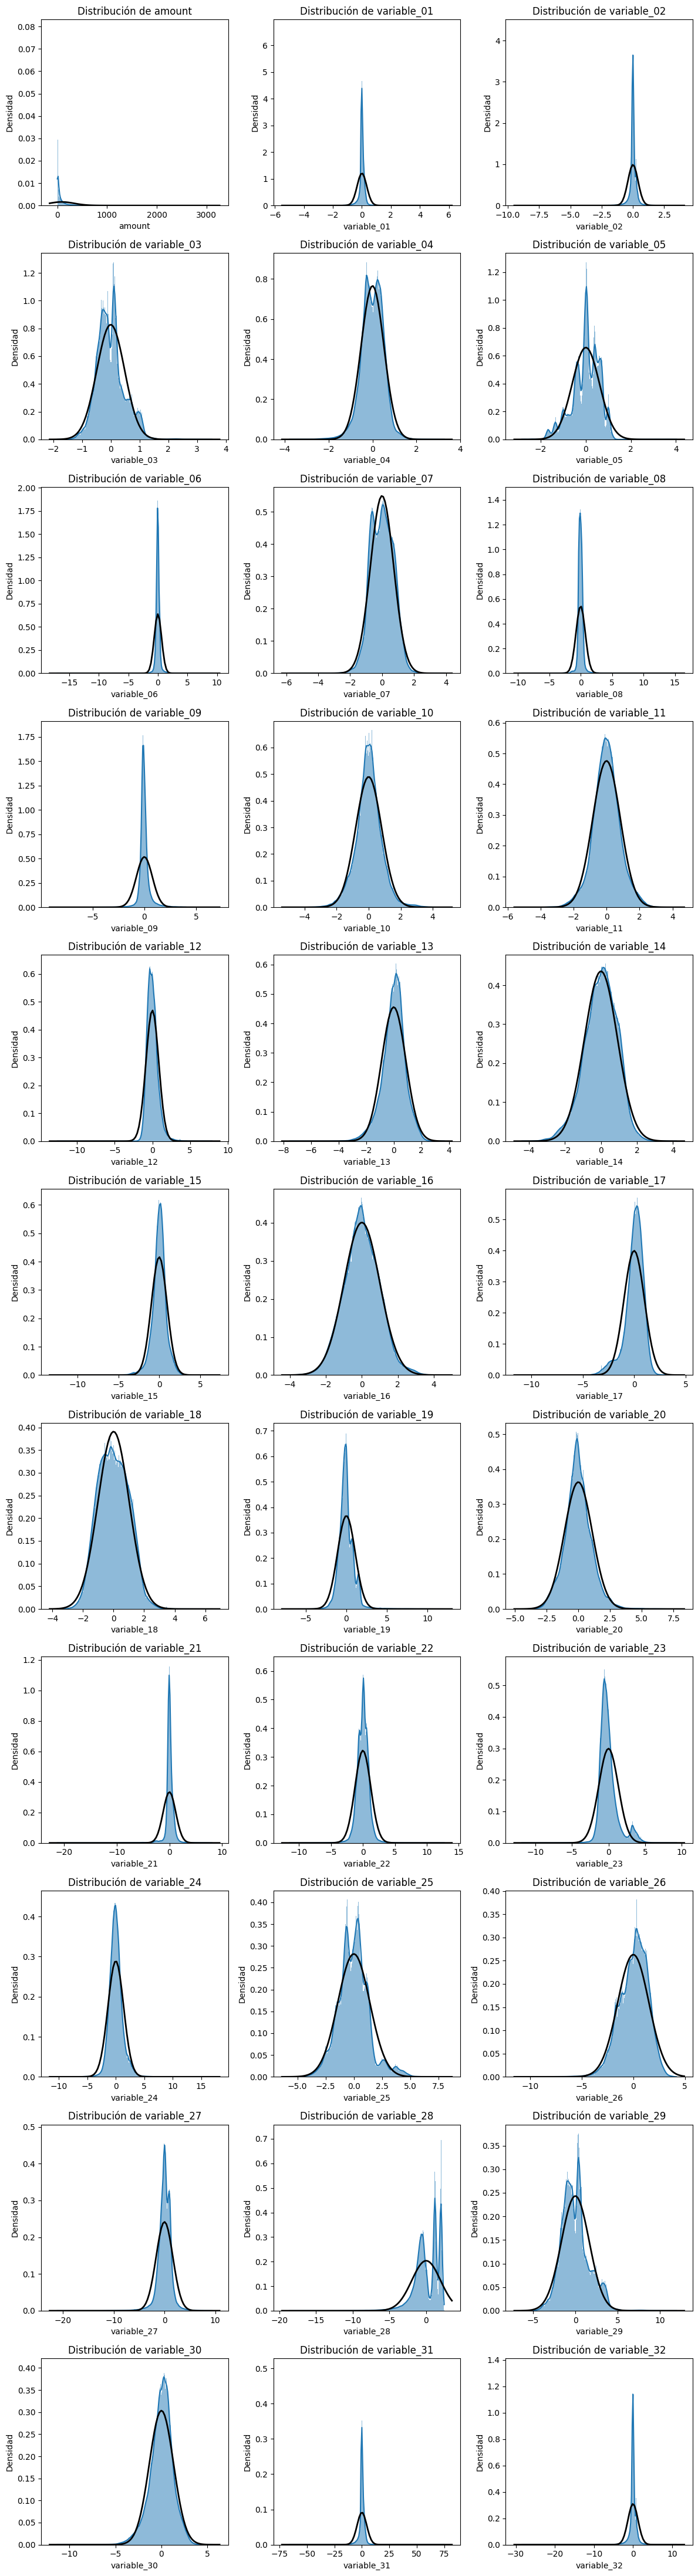

In [301]:
list_descart = ['transaction_id','is_fraud','timestamp', 'outlier_score']
#list_descart = ['transaction_id','is_fraud','timestamp']
df_column_cont = df.drop(columns = list_descart)
list_column = df_column_cont.columns

num_var = len(list_column)
cols = 3
rows = (num_var // cols) + (num_var % cols > 0)
plt.figure(figsize=(cols * 4, rows * 4))
for i, var in enumerate(list_column, 1):
    plt.subplot(rows, cols, i)  
    sns.histplot(df_sin_out[var], kde=True, stat="density", linewidth=0)
    
    mu, std = norm.fit(df[var].dropna())  
    xmin, xmax = plt.xlim()
    x = np.linspace(xmin, xmax, 100)
    p = norm.pdf(x, mu, std)
    plt.plot(x, p, 'k', linewidth=2)
    
    plt.title(f'Distribución de {var}')
    plt.xlabel(var)
    plt.ylabel('Densidad')

plt.tight_layout()
plt.show() # Al aplicar isolation forest se pueden ver algunas caractersitcas que quedaron mucho mejor, sin embargo hay otras que aun 
           # siguen teniendo outliers drasticos. Por lo que vamos a hacer otro tratamiento de outliers 

In [302]:
df_sin_out['amount_log'] = np.log1p(df_sin_out['amount']) # En la caractersitca amount hay una distribucion logaritmica
                                                      # por lo que aplicamos log1p para linealizar la relacion

/tmp/ipykernel_5765/1453168980.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sin_out['amount_log'] = np.log1p(df_sin_out['amount']) # En la caractersitca amount hay una distribucion logaritmica


<Axes: xlabel='amount_log', ylabel='Density'>

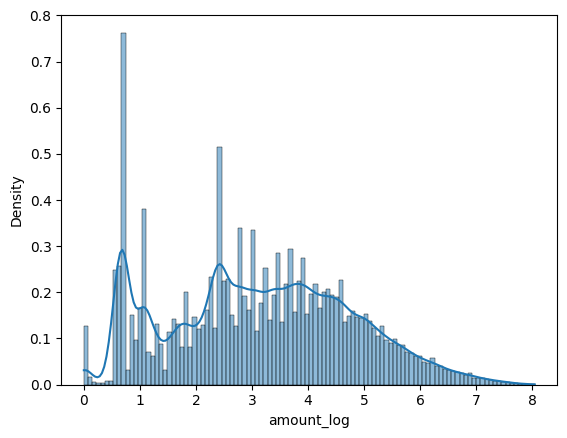

In [303]:
sns.histplot(df_sin_out['amount_log'],kde = True, stat = 'density')

In [304]:
df_sin_out.isnull().sum()

transaction_id    0
timestamp         0
amount            0
variable_01       0
variable_02       0
variable_03       0
variable_04       0
variable_05       0
variable_06       0
variable_07       0
variable_08       0
variable_09       0
variable_10       0
variable_11       0
variable_12       0
variable_13       0
variable_14       0
variable_15       0
variable_16       0
variable_17       0
variable_18       0
variable_19       0
variable_20       0
variable_21       0
variable_22       0
variable_23       0
variable_24       0
variable_25       0
variable_26       0
variable_27       0
variable_28       0
variable_29       0
variable_30       0
variable_31       0
variable_32       0
is_fraud          0
outlier_score     0
amount_log        0
dtype: int64

# Ingenieria de Variables

In [305]:
x = df_sin_out[list_column]
y = df_sin_out['is_fraud']

In [306]:
y.value_counts()

is_fraud
0    281726
1       232
Name: count, dtype: int64

In [307]:
Xt, Xv, yt, yv = train_test_split(x,y,train_size = 0.7 ,stratify = y, random_state = 666)

Ya que las variables son secretas aplicamos f_classi para obtener las variables con mayor varianza y hacer Ing de variables con las top varaibles y jugaremos un poco con ellas ya que no sabemos la naturaleza de las caracteristicas

In [308]:
sc_kbest = StandardScaler()
x_sc = sc_kbest.fit_transform(Xt)

In [309]:
Sel_K = SelectKBest(score_func = f_classif, k = 'all')
Sel_K.fit_transform(x_sc, yt)

array([[-0.0296522 , -0.14793928,  0.13383515, ...,  0.50741039,
        -0.14793928,  0.13383515],
       [-0.29046205, -0.1781715 , -0.16377132, ...,  0.42317311,
        -0.1781715 , -0.16377132],
       [-0.44142189, -0.34403799, -0.22408792, ...,  0.222089  ,
        -0.34403799, -0.22408792],
       ...,
       [ 5.94565064,  0.91155801, -0.65963379, ..., -0.77708472,
         0.91155801, -0.65963379],
       [-0.40221372,  0.68100525,  0.66089843, ...,  0.21315858,
         0.68100525,  0.66089843],
       [-0.24683527,  0.08145729,  0.03175245, ...,  0.45359756,
         0.08145729,  0.03175245]])

In [310]:
Importancia_Caracteristica = pd.DataFrame({
    'Caracteristica': x.columns,
    'F_Score': Sel_K.scores_
}).sort_values(by = 'F_Score', ascending=False)

In [311]:
Importancia_Caracteristica

,Caracteristica,F_Score
15,variable_15,4589.220136
17,variable_17,1720.086374
12,variable_12,1250.461991
19,variable_19,1183.318004
18,variable_18,707.901346
25,variable_25,632.303449
26,variable_26,559.795992
13,variable_13,443.962054
30,variable_30,443.962054
20,variable_20,202.939575


In [312]:
top_5 = Importancia_Caracteristica.head(5)['Caracteristica'].values
top_2 = Importancia_Caracteristica.head(2)['Caracteristica'].values

In [313]:
Xt['top_5_mean'] = Xt[top_5].mean(axis=1)
Xt['top_5_std'] = Xt[top_5].std(axis=1)
Xt['top_5_sum'] = Xt[top_5].sum(axis=1)
Xt['top_5_min'] = Xt[top_5].min(axis=1)
Xt['top_5_max'] = Xt[top_5].max(axis=1)
Xt['top_5_prod'] = Xt[top_5].prod(axis=1)
Xt['top_2_prod'] = Xt[top_2].prod(axis=1)
Xt['top_5_prod'] = np.sqrt(np.abs(Xt['top_5_prod']))
Xt['top_2_prod'] = np.sqrt(np.abs(Xt['top_2_prod']))
Xt['top_5_prod'] = np.log1p(Xt['top_5_prod'])
Xt['top_2_prod'] = np.log1p(Xt['top_2_prod'])


In [314]:
Xv['top_5_mean'] = Xv[top_5].mean(axis=1)
Xv['top_5_std'] = Xv[top_5].std(axis=1)
Xv['top_5_sum'] = Xv[top_5].sum(axis=1)
Xv['top_5_min'] = Xv[top_5].min(axis=1)
Xv['top_5_max'] = Xv[top_5].max(axis=1)
Xv['top_5_prod'] = Xv[top_5].prod(axis=1)
Xv['top_2_prod'] = Xv[top_2].prod(axis=1)
Xv['top_5_prod'] = np.sqrt(np.abs(Xv['top_5_prod']))
Xv['top_2_prod'] = np.sqrt(np.abs(Xv['top_2_prod']))
Xv['top_5_prod'] = np.log1p(Xv['top_5_prod'])
Xv['top_2_prod'] = np.log1p(Xv['top_2_prod'])


In [315]:
Xt

,amount,variable_01,variable_02,variable_03,variable_04,variable_05,variable_06,variable_07,variable_08,variable_09,variable_10,variable_11,variable_12,variable_13,variable_14,variable_15,variable_16,variable_17,variable_18,variable_19,variable_20,variable_21,variable_22,variable_23,variable_24,variable_25,variable_26,variable_27,variable_28,variable_29,variable_30,variable_31,variable_32,top_5_mean,top_5_std,top_5_sum,top_5_min,top_5_max,top_5_prod,top_2_prod
105736,75.60,-0.030443,0.041768,-0.242057,-0.555180,-0.022939,0.250301,0.100639,-0.063978,-0.299653,0.028378,1.150331,-0.167786,0.422764,-0.107672,-0.522482,-0.258229,-0.773134,-0.047077,1.656639,-0.709264,0.326739,-1.980151,0.662974,-1.594893,-1.762343,-0.350498,-1.949977,2.118534,-0.822992,0.634146,-0.401844,0.133657,0.029232,0.954106,0.146161,-0.773134,1.656639,0.070183,0.491991
171299,28.97,-0.036986,-0.050380,-0.276412,0.028334,-0.806698,-0.176682,0.386106,0.169942,0.006968,1.061622,0.899895,-0.765411,0.352838,0.273265,0.585385,1.063803,0.823621,0.155309,-0.238120,-1.013150,0.427801,0.355219,0.193155,0.374646,0.615705,0.234769,1.156554,-0.267106,-0.939802,0.529257,-0.488222,-0.161217,0.112157,0.637340,0.560784,-0.765411,0.823621,0.110488,0.527305
198243,1.98,-0.072888,-0.069056,0.204820,-0.233180,-0.466888,0.257465,-0.597290,-0.257930,-0.137212,0.608650,-0.334406,-0.765664,0.185917,-0.728899,0.256149,1.004153,1.470835,0.692318,0.215121,0.171912,-0.210941,0.135684,-0.594182,0.229899,0.179659,-1.223907,-0.045942,2.053257,0.696387,0.278876,-0.962126,-0.220980,0.373752,0.812763,1.868759,-0.765664,1.470835,0.188364,0.478593
224824,600.00,-0.292022,-0.365527,0.229907,0.574451,-0.007107,1.133943,-1.028049,0.370194,1.547746,-0.526727,0.975187,-1.196401,1.428236,-0.145360,0.763352,-1.380944,-0.192751,-0.181515,-2.223113,0.185974,0.694610,1.141741,0.026700,-0.262771,-2.022059,0.228490,-3.062405,-3.519474,0.781682,2.142355,-3.854695,-1.169688,-0.606086,1.139047,-3.030428,-2.223113,0.763352,0.236276,0.324677
181725,4.79,-0.006596,-0.004267,0.471113,0.522832,-0.238138,-0.108345,0.149271,-0.033641,-0.146537,0.243606,-0.392908,0.006249,-0.359572,-0.809026,0.042377,-0.257203,1.060418,0.815645,-0.083077,0.398857,0.212981,-0.330684,0.379456,-0.242540,0.648979,0.459047,-0.105625,1.165786,1.601784,-0.539359,-0.087062,-0.013655,0.368322,0.529196,1.841612,-0.083077,1.060418,0.004353,0.192259
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
88774,16.52,0.073340,-0.078655,0.145444,0.932361,0.007686,-0.649032,0.699696,0.223059,0.063608,0.450436,0.712437,0.697201,-0.205963,1.110361,-0.881385,0.280328,-0.284482,-0.335926,-1.140434,-0.641675,-0.336916,1.258422,-1.033076,0.659367,-0.121171,0.638692,1.418623,-0.603695,0.494510,-0.308945,0.968091,-0.251696,-0.389005,0.707225,-1.945026,-1.140434,0.697201,0.230150,0.405957
232108,55.00,-0.044276,-0.029849,-0.341502,-0.160492,0.567356,0.283748,-0.529986,-0.291630,-0.315767,-0.121049,-0.472848,0.429871,-0.657293,0.154612,-0.061008,0.785393,-0.732707,-0.774207,1.627644,-1.803378,-0.384020,-0.522098,-0.915560,-0.637140,-1.692260,-1.636343,-1.194623,2.273578,-1.161106,-0.985939,-0.584447,-0.095516,0.097919,0.990713,0.489593,-0.774207,1.627644,0.144628,0.191798
194628,1143.92,0.198886,-0.203915,-0.150104,0.297801,-0.073152,-1.131768,-0.847262,0.431630,1.904211,-0.114857,0.185460,0.782876,-0.643501,-0.106389,0.055177,-0.325647,-1.388400,-1.305697,0.890972,-1.771333,-0.523085,0.745381,-0.384399,-2.296942,-0.385812,-1.376208,-4.620659,-0.618131,-0.510353,-0.965252,2.625289,-0.652527,-0.193014,1.101816,-0.965071,-1.388400,0.890972,0.234393,0.244342
138577,8.99,0.148982,0.204963,0.144377,-0.339976,-0.392123,0.134489,-0.486585,-0.223846,0.137137,0.194388,-0.325825,-0.622994,0.178504,-1.110422,0.285797,0.776625,1.302644,0.560531,0.229773,-0.111134,0.351524,0.572982,-0.589318,0.294420,-0.869607,-0.431543,1.470924,-0.921653,0.490883,0.267756,1.966567

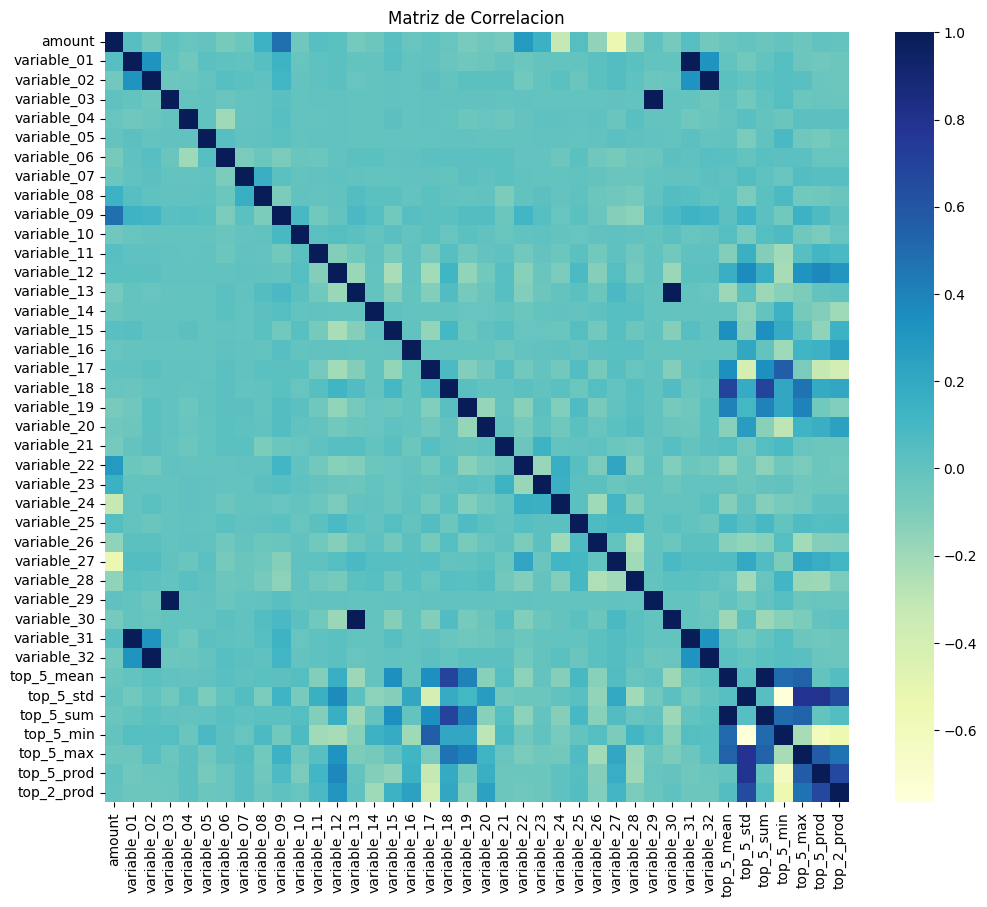

In [316]:
matrix_corr = Xt.corr()
plt.figure(figsize = (12,10))
plt.title('Matriz de Correlacion')
sns.heatmap(matrix_corr, cmap = 'YlGnBu')
plt.show()

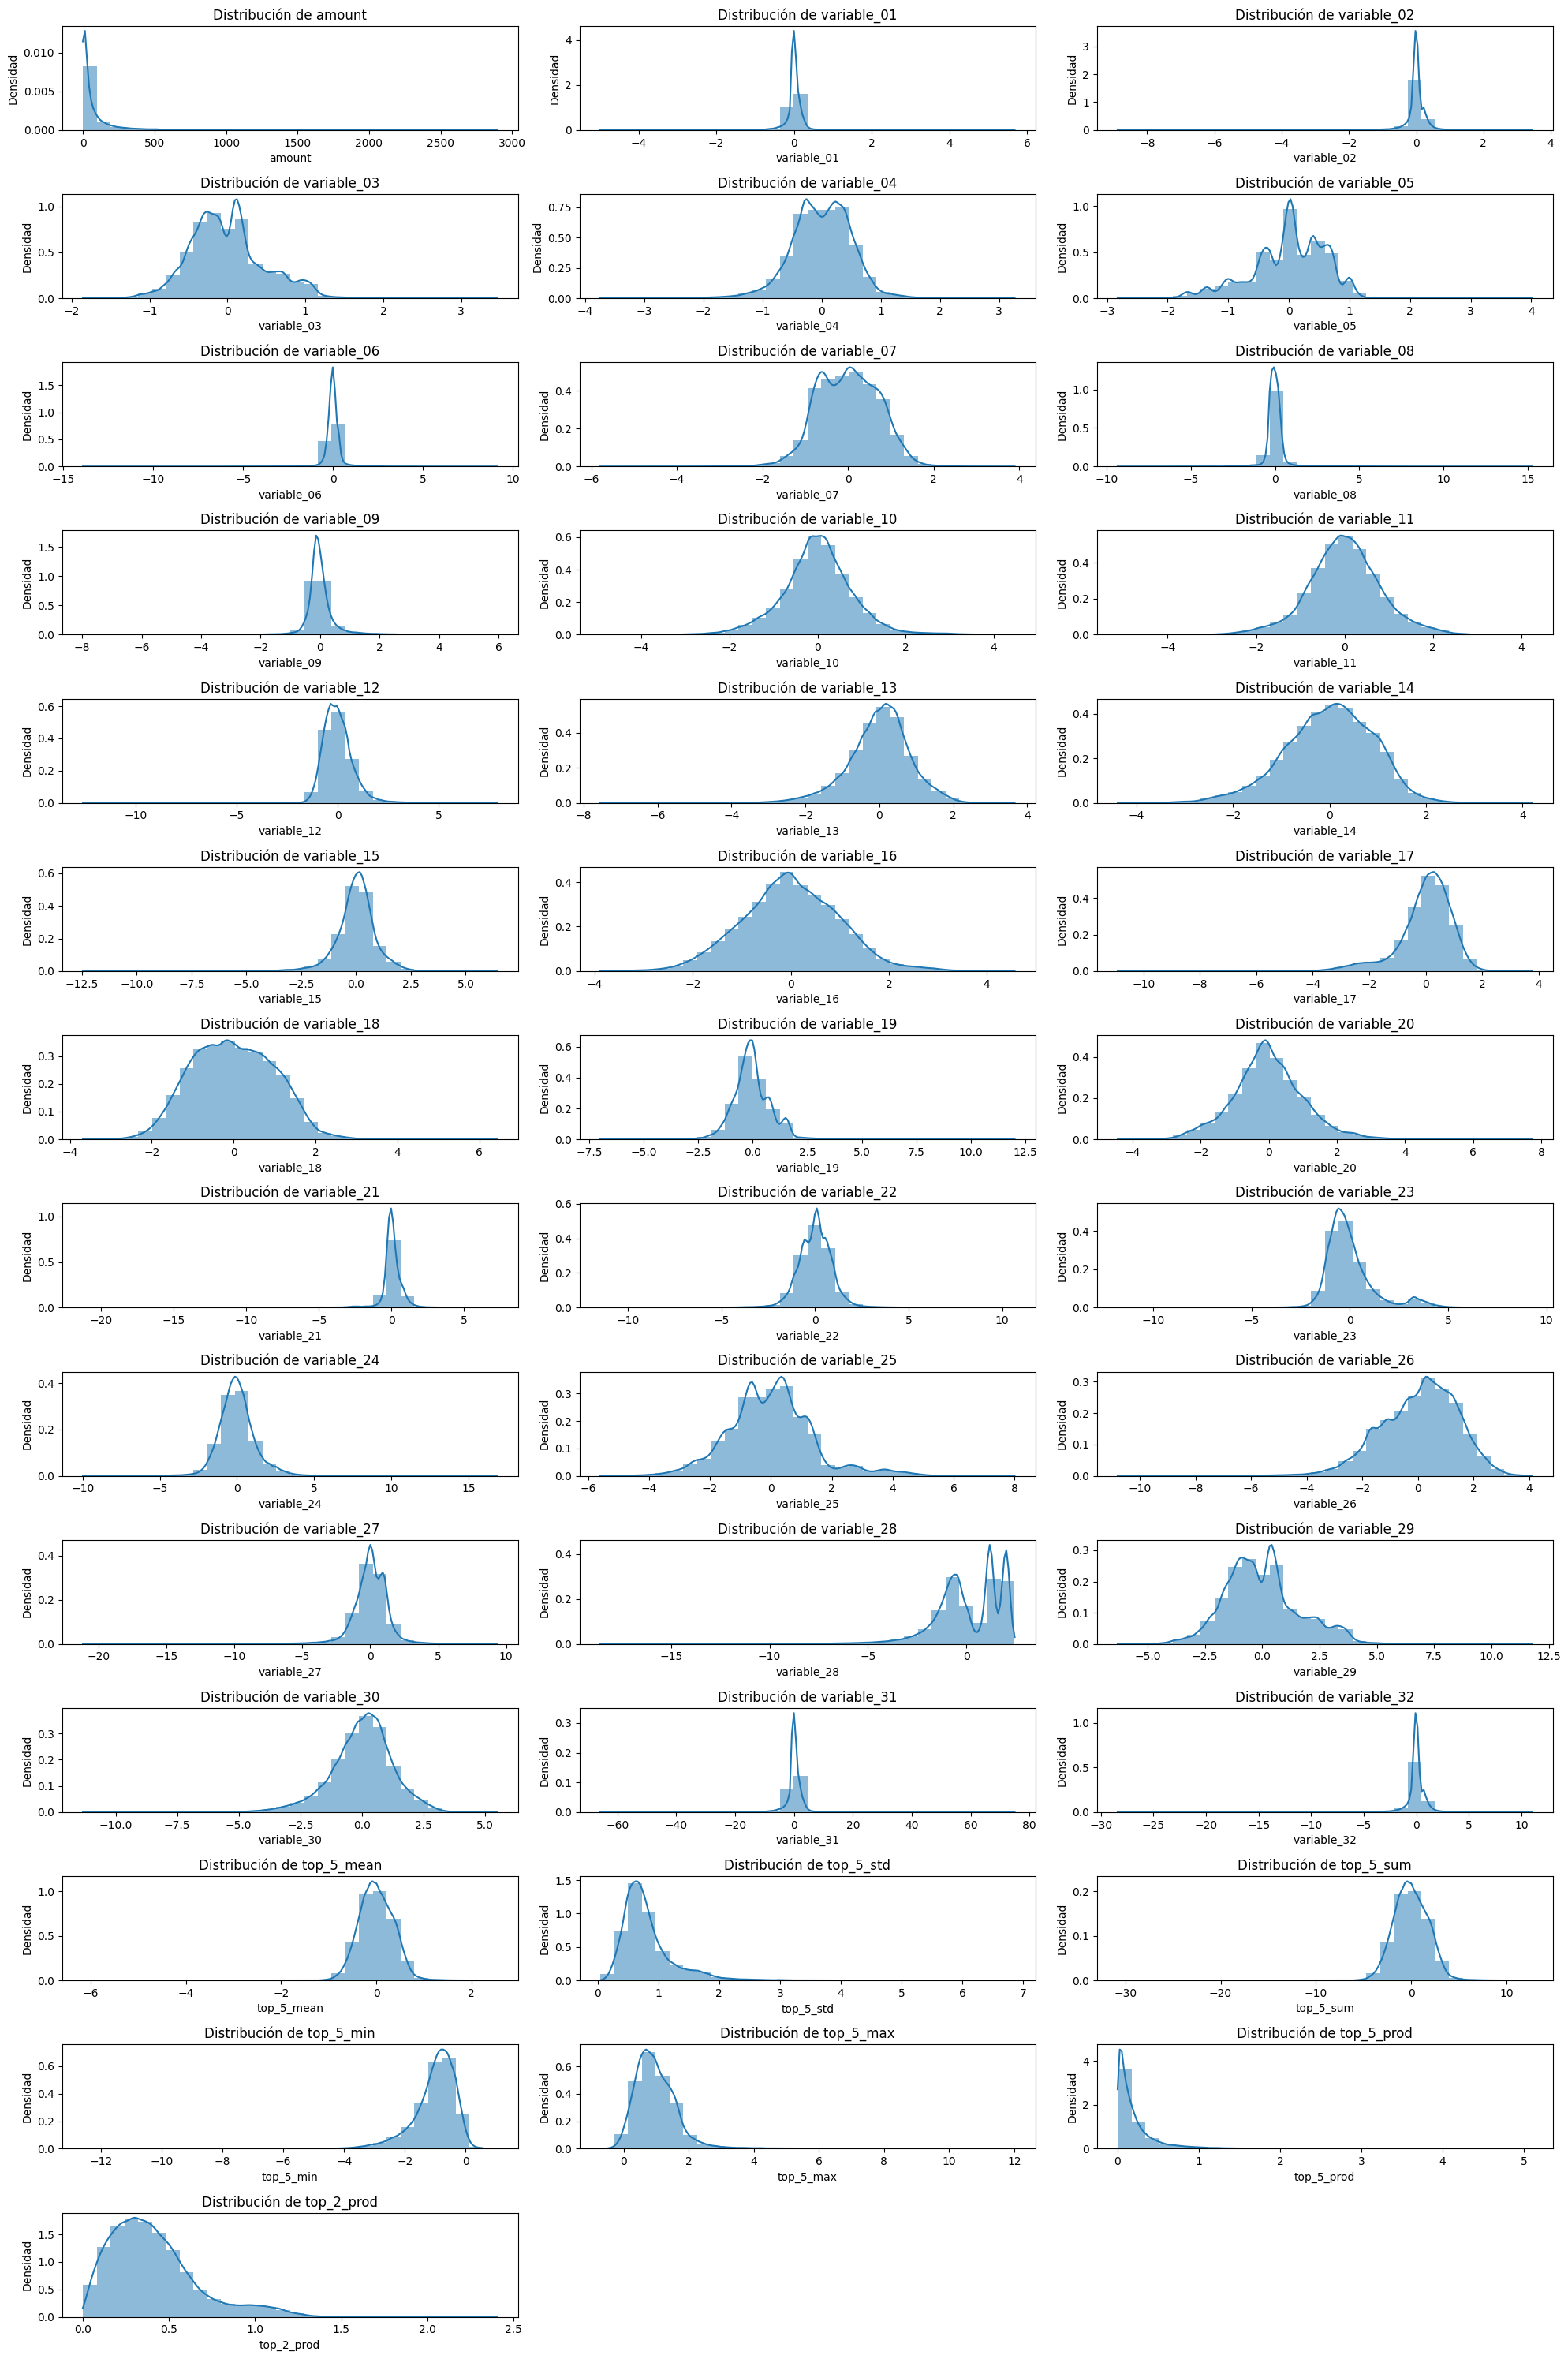

In [317]:
list_column = Xt.columns

num_var = len(list_column)
plt.figure(figsize=(20, 30))
for i, var in enumerate(list_column, 1):
    plt.subplot(14, 3, i)  
    sns.histplot(Xt[var], kde=True, stat="density", linewidth=0, bins=30)
    plt.title(f'Distribución de {var}')
    plt.xlabel(var)
    plt.ylabel('Densidad')

plt.tight_layout()
plt.show()

In [318]:
Xt.isnull().sum()

amount         0
variable_01    0
variable_02    0
variable_03    0
variable_04    0
variable_05    0
variable_06    0
variable_07    0
variable_08    0
variable_09    0
variable_10    0
variable_11    0
variable_12    0
variable_13    0
variable_14    0
variable_15    0
variable_16    0
variable_17    0
variable_18    0
variable_19    0
variable_20    0
variable_21    0
variable_22    0
variable_23    0
variable_24    0
variable_25    0
variable_26    0
variable_27    0
variable_28    0
variable_29    0
variable_30    0
variable_31    0
variable_32    0
top_5_mean     0
top_5_std      0
top_5_sum      0
top_5_min      0
top_5_max      0
top_5_prod     0
top_2_prod     0
dtype: int64

In [319]:
Xt_c = Xt.copy()
sc = StandardScaler()
Xt = sc.fit_transform(Xt) # Normalizamos las variables recien creadas
Xv = sc.transform(Xv)

In [320]:
Xt

array([[-0.0296522 , -0.14793928,  0.13383515, ...,  0.92263825,
        -0.50679297,  0.32599361],
       [-0.29046205, -0.1781715 , -0.16377132, ..., -0.244962  ,
        -0.35263963,  0.46389786],
       [-0.44142189, -0.34403799, -0.22408792, ...,  0.66220556,
        -0.05479127,  0.2736746 ],
       ...,
       [ 5.94565064,  0.91155801, -0.65963379, ..., -0.15055919,
         0.12125635, -0.64109712],
       [-0.40221372,  0.68100525,  0.66089843, ...,  0.4264608 ,
        -0.16547526,  0.26484262],
       [-0.24683527,  0.08145729,  0.03175245, ..., -0.65303401,
        -0.72985554, -1.13045541]])

In [321]:
Xv

array([[-0.43745074,  0.5327157 ,  0.86348315, ..., -1.36211167,
        -0.7395129 , -1.5016839 ],
       [-0.18765945,  0.31185713,  0.39572474, ...,  0.19508617,
         0.51162135,  0.34894029],
       [-0.36652925, -0.42224651,  0.26516676, ...,  0.49413807,
         0.51847313,  2.78527268],
       ...,
       [-0.07915182,  0.55851355,  0.74061349, ..., -0.25315874,
        -0.31974703, -0.53283113],
       [-0.45249638, -0.03932885, -0.20741881, ...,  0.70829705,
        -0.6390583 , -0.14220761],
       [-0.43012368,  0.63286675, -0.12099905, ...,  1.53792005,
         0.31649569,  2.79408626]])

In [322]:
Xt.shape

(197370, 40)

In [323]:
len(yt)

197370

In [324]:
df_mf = pd.DataFrame(Xt, columns = Xt_c.columns)
df_mf['y'] = yt.reset_index(drop = True)

### WOE

In [325]:
# Discretizamos las variables continuas, ademas calculamos IV y WOE
lst = []
woe_info = {}
df_raw  = df_mf.copy()
for i,l in enumerate(list_column):
    bestk = 0
    best_iv = 0
    for k in range (2,10):
        aux = df_mf[[l,'y']].copy()
        aux[l] = pd.cut(aux[l], bins = k, include_lowest = True).astype(str)
        aux['n'] = 1
        aux = aux.pivot_table(index = l, columns = 'y', aggfunc = 'count')
        aux.columns = aux.columns.droplevel()
        aux.reset_index(inplace = True)
        #aux[0] = aux[0] + 1e-6  
        #aux[1] = aux[1] + 1e-6
        for i in range(2):
            aux[i] /= aux[i].sum()
        aux['WOE'] = np.log(aux[0]/aux[1])
        aux['IV'] = aux['WOE']*(aux[0]-aux[1])
        if(aux['IV'].sum() > best_iv) & (~np.isinf(aux['IV'].sum())):
            best_iv = aux['IV'].sum()
            bestk = k
    aux = df_mf[[l,'y']].copy()
    print("%s %.4f %d" % (l,best_iv,bestk))
    if best_iv >= 0.02:
        lst.append(l)
    aux[l] = pd.cut(aux[l], bins = bestk, include_lowest = True).astype(str)
    aux['n'] = 1
    aux = aux.pivot_table(index = l, columns = 'y', aggfunc = 'count')
    aux.columns = aux.columns.droplevel()
    aux.reset_index(inplace = True)
    for i in range(2):
        aux[i] /= aux[i].sum()
    aux['WOE'] = np.log(aux[0]/aux[1])
    aux['WOE'] = aux['WOE'].fillna(0) # Se uso Fillna para evitar los Nan y perder columnas a la hora de entrenar
    df_mf[l] = pd.cut(df_mf[l], bins = bestk, include_lowest = True).astype(str)
    df_mf = df_mf.merge(aux[['WOE',l]], how = 'inner', on = l)
    df_mf.rename(columns = {'WOE':'W_%s'%l}, inplace = True)
    _, bin_edges = pd.cut(df_raw[l], bins=bestk, include_lowest=True, retbins=True)
    woe_info[l] = {
    'bins': bin_edges,  # Esto es un array de límites para usar con pd.cut en test
    'woe_map': aux.set_index(l)['WOE'].to_dict()
    }


amount 0.1060 9
variable_01 0.2091 6
variable_02 0.8376 8
variable_03 0.0570 6
variable_04 0.1170 8
variable_05 0.1880 8
variable_06 0.0563 9
variable_07 0.0534 8
variable_08 0.6606 5
variable_09 0.1688 7
variable_10 0.4575 9
variable_11 0.9175 7
variable_12 4.9475 8
variable_13 1.7816 7
variable_14 0.0668 8
variable_15 4.9119 8
variable_16 0.1706 8
variable_17 3.5679 7
variable_18 2.8307 9
variable_19 4.1986 9
variable_20 1.0287 7
variable_21 0.1118 9
variable_22 1.1243 9
variable_23 0.6345 6
variable_24 0.2446 7
variable_25 2.7498 9
variable_26 2.0485 7
variable_27 0.9208 7
variable_28 0.2792 6
variable_29 0.0570 6
variable_30 1.7816 7
variable_31 0.2091 6
variable_32 0.8376 8
top_5_mean 5.8083 2
top_5_std 4.6664 6
top_5_sum 5.8083 2
top_5_min 5.7948 7
top_5_max 2.2616 9
top_5_prod 5.8977 9
top_2_prod 5.0660 9


In [326]:
woe_info

{'amount': {'bins': array([-0.46869367,  1.34720153,  3.14689945,  4.94659737,  6.74629528,
          8.5459932 , 10.34569111, 12.14538903, 13.94508695, 15.74478486]),
  'woe_map': {'(-0.47, 1.347]': 0.08895655790828413,
   '(1.347, 3.147]': -0.6391218851542656,
   '(10.346, 12.145]': -2.4409788589346824,
   '(12.145, 13.945]': 0.0,
   '(13.945, 15.745]': 0.0,
   '(3.147, 4.947]': -1.542775245551671,
   '(4.947, 6.746]': -0.2692333668994477,
   '(6.746, 8.546]': -1.0594126390107375,
   '(8.546, 10.346]': 0.0}},
 'variable_01': {'bins': array([-23.09957246, -14.83721414,  -6.6241343 ,   1.58894554,
           9.80202539,  18.01510523,  26.22818507]),
  'woe_map': {'(-14.837, -6.624]': -1.2666875058808096,
   '(-23.101000000000003, -14.837]': 0.0,
   '(-6.624, 1.589]': 0.11683229656004035,
   '(1.589, 9.802]': -1.8386237782042727,
   '(18.015, 26.228]': 0.0,
   '(9.802, 18.015]': 0.0}},
 'variable_02': {'bins': array([-28.71586026, -23.70107683, -18.72609327, -13.7511097 ,
          -8.7

In [327]:
df_mf

,amount,variable_01,variable_02,variable_03,variable_04,variable_05,variable_06,variable_07,variable_08,variable_09,variable_10,variable_11,variable_12,variable_13,variable_14,variable_15,variable_16,variable_17,variable_18,variable_19,variable_20,variable_21,variable_22,variable_23,variable_24,variable_25,variable_26,variable_27,variable_28,variable_29,variable_30,variable_31,variable_32,top_5_mean,top_5_std,top_5_sum,top_5_min,top_5_max,top_5_prod,top_2_prod,y,W_amount,W_variable_01,W_variable_02,W_variable_03,W_variable_04,W_variable_05,W_variable_06,W_variable_07,W_variable_08,W_variable_09,W_variable_10,W_variable_11,W_variable_12,W_variable_13,W_variable_14,W_variable_15,W_variable_16,W_variable_17,W_variable_18,W_variable_19,W_variable_20,W_variable_21,W_variable_22,W_variable_23,W_variable_24,W_variable_25,W_variable_26,W_variable_27,W_variable_28,W_variable_29,W_variable_30,W_variable_31,W_variable_32,W_top_5_mean,W_top_5_std,W_top_5_sum,W_top_5_min,W_top_5_max,W_top_5_prod,W_top_2_prod
0,"(-0.47, 1.347]","(-6.624, 1.589]","(-3.801, 1.174]","(-2.018, -0.174]","(-2.202, -0.469]","(-0.431, 0.984]","(-2.563, 3.364]","(-1.347, 0.369]","(-7.673, 0.865]","(-3.764, -0.0316]","(-0.934, 0.365]","(0.27, 1.907]","(-3.244, 0.276]","(-1.381, 0.549]","(-1.282, -0.103]","(-0.754, 1.963]","(-0.721, 0.342]","(-2.699, -0.458]","(-0.303, 0.826]","(1.531, 3.753]","(-0.911, 0.744]","(-2.417, 1.004]","(-4.306, -1.723]","(-1.006, 1.785]","(-1.985, 1.286]","(-1.865, -0.766]","(-1.703, -0.148]","(-2.847, 0.471]","(-0.694, 1.432]","(-2.018, -0.174]","(-1.381, 0.549]","(-6.624, 1.589]","(-3.801, 1.174]","(-4.974, 6.97]","(-1.7699999999999998, 0.841]","(-4.974, 6.97]","(0.157, 2.918]","(-0.425, 1.558]","(-0.796, 1.393]","(-0.55, 0.494]",0,0.088957,0.116832,0.459015,0.017435,0.571162,-0.113924,0.039948,-0.103746,0.368185,0.397831,0.530528,0.255508,1.233463,1.074069,0.032590,1.923807,0.351705,-0.099117,1.006200,1.092019,0.561264,0.120501,-2.473336,0.27183,0.169402,3.331725,-0.059556,1.078105,0.364384,0.017435,1.074069,0.116832,0.459015,0.913118,1.714993,0.913118,2.336727,0.583299,1.398287,1.466470
1,"(-0.47, 1.347]","(-6.624, 1.589]","(-3.801, 1.174]","(-2.018, -0.174]","(-0.469, 1.264]","(-1.846, -0.431]","(-2.563, 3.364]","(0.369, 2.085]","(-7.673, 0.865]","(-0.0316, 3.701]","(0.365, 1.663]","(0.27, 1.907]","(-3.244, 0.276]","(-1.381, 0.549]","(-0.103, 1.076]","(-0.754, 1.963]","(0.342, 1.405]","(-0.458, 1.783]","(-0.303, 0.826]","(-0.691, 1.531]","(-2.565, -0.911]","(-2.417, 1.004]","(-1.723, 0.859]","(-1.006, 1.785]","(-1.985, 1.286]","(0.334, 1.433]","(-0.148, 1.408]","(0.471, 3.79]","(-0.694, 1.432]","(-2.018, -0.174]","(-1.381, 0.549]","(-6.624, 1.589]","(-3.801, 1.174]","(-4.974, 6.97]","(-1.7699999999999998, 0.841]","(-4.974, 6.97]","(0.157, 2.918]","(-0.425, 1.558]","(-0.796, 1.393]","(-0.55, 0.494]",0,0.088957,0.116832,0.459015,0.017435,-0.102995,-0.277382,0.039948,0.092919,0.368185,-0.334007,0.240301,0.255508,1.233463,1.074069,0.125409,1.923807,-0.046717,1.503063,1.006200,1.203076,-1.031893,0.120501,0.590449,0.27183,0.169402,0.047068,1.466913,-0.938690,0.364384,0.017435,1.074069,0.116832,0.459015,0.913118,1.714993,0.913118,2.336727,0.583299,1.398287,1.466470
2,"(-0.47, 1.347]","(-6.624, 1.589]","(-3.801, 1.174]","(-0.174, 1.67]","(-0.469, 1.264]","(-1.846, -0.431]","(-2.563, 3.364]","(-1.347, 0.369]","(-7.673, 0.865]","(-3.764, -0.0316]","(0.365, 1.663]","(-1.366, 0.27]","(-3.244, 0.276]","(-1.381, 0.549]","(-1.282, -0.103]","(-0.754, 1.963]","(0.342, 1.405]","(-0.458, 1.783]","(-0.303, 0.826]","(-0.691, 1.531]","(-0.911, 0.744]","(-2.417, 1.004]","(-1.723, 0.859]","(-1.006, 1.785]","(-1.985, 1.286]","(-0.766, 0.334]","(-1.703, -0.148]","(-2.847, 0.471]","(-0.694, 1.432]","(-0.174, 1.67]","(-1.381, 0.549]","(-6.624, 1.589]","(-3.801, 1.174]","(-4.974, 6.97]","(-1.7699999999999998, 0.841]","(-4.974, 6.97]","(0.157, 2.918]","(-0.425, 1.558]","(-0.796, 1.393]","(-0.55, 0.494]",0,0.088957,0.116832,0.459015,-0.099816,-0.102995,-0.277382,0.0

In [328]:
list_column

Index(['amount', 'variable_01', 'variable_02', 'variable_03', 'variable_04',
       'variable_05', 'variable_06', 'variable_07', 'variable_08',
       'variable_09', 'variable_10', 'variable_11', 'variable_12',
       'variable_13', 'variable_14', 'variable_15', 'variable_16',
       'variable_17', 'variable_18', 'variable_19', 'variable_20',
       'variable_21', 'variable_22', 'variable_23', 'variable_24',
       'variable_25', 'variable_26', 'variable_27', 'variable_28',
       'variable_29', 'variable_30', 'variable_31', 'variable_32',
       'top_5_mean', 'top_5_std', 'top_5_sum', 'top_5_min', 'top_5_max',
       'top_5_prod', 'top_2_prod'],
      dtype='object')

In [329]:
varw = ['W_'+i for i in list_column]
df_mf = df_mf.dropna(axis=0,subset=['y']).reset_index(drop=True).copy()

In [330]:
df_mf

,amount,variable_01,variable_02,variable_03,variable_04,variable_05,variable_06,variable_07,variable_08,variable_09,variable_10,variable_11,variable_12,variable_13,variable_14,variable_15,variable_16,variable_17,variable_18,variable_19,variable_20,variable_21,variable_22,variable_23,variable_24,variable_25,variable_26,variable_27,variable_28,variable_29,variable_30,variable_31,variable_32,top_5_mean,top_5_std,top_5_sum,top_5_min,top_5_max,top_5_prod,top_2_prod,y,W_amount,W_variable_01,W_variable_02,W_variable_03,W_variable_04,W_variable_05,W_variable_06,W_variable_07,W_variable_08,W_variable_09,W_variable_10,W_variable_11,W_variable_12,W_variable_13,W_variable_14,W_variable_15,W_variable_16,W_variable_17,W_variable_18,W_variable_19,W_variable_20,W_variable_21,W_variable_22,W_variable_23,W_variable_24,W_variable_25,W_variable_26,W_variable_27,W_variable_28,W_variable_29,W_variable_30,W_variable_31,W_variable_32,W_top_5_mean,W_top_5_std,W_top_5_sum,W_top_5_min,W_top_5_max,W_top_5_prod,W_top_2_prod
0,"(-0.47, 1.347]","(-6.624, 1.589]","(-3.801, 1.174]","(-2.018, -0.174]","(-2.202, -0.469]","(-0.431, 0.984]","(-2.563, 3.364]","(-1.347, 0.369]","(-7.673, 0.865]","(-3.764, -0.0316]","(-0.934, 0.365]","(0.27, 1.907]","(-3.244, 0.276]","(-1.381, 0.549]","(-1.282, -0.103]","(-0.754, 1.963]","(-0.721, 0.342]","(-2.699, -0.458]","(-0.303, 0.826]","(1.531, 3.753]","(-0.911, 0.744]","(-2.417, 1.004]","(-4.306, -1.723]","(-1.006, 1.785]","(-1.985, 1.286]","(-1.865, -0.766]","(-1.703, -0.148]","(-2.847, 0.471]","(-0.694, 1.432]","(-2.018, -0.174]","(-1.381, 0.549]","(-6.624, 1.589]","(-3.801, 1.174]","(-4.974, 6.97]","(-1.7699999999999998, 0.841]","(-4.974, 6.97]","(0.157, 2.918]","(-0.425, 1.558]","(-0.796, 1.393]","(-0.55, 0.494]",0,0.088957,0.116832,0.459015,0.017435,0.571162,-0.113924,0.039948,-0.103746,0.368185,0.397831,0.530528,0.255508,1.233463,1.074069,0.032590,1.923807,0.351705,-0.099117,1.006200,1.092019,0.561264,0.120501,-2.473336,0.27183,0.169402,3.331725,-0.059556,1.078105,0.364384,0.017435,1.074069,0.116832,0.459015,0.913118,1.714993,0.913118,2.336727,0.583299,1.398287,1.466470
1,"(-0.47, 1.347]","(-6.624, 1.589]","(-3.801, 1.174]","(-2.018, -0.174]","(-0.469, 1.264]","(-1.846, -0.431]","(-2.563, 3.364]","(0.369, 2.085]","(-7.673, 0.865]","(-0.0316, 3.701]","(0.365, 1.663]","(0.27, 1.907]","(-3.244, 0.276]","(-1.381, 0.549]","(-0.103, 1.076]","(-0.754, 1.963]","(0.342, 1.405]","(-0.458, 1.783]","(-0.303, 0.826]","(-0.691, 1.531]","(-2.565, -0.911]","(-2.417, 1.004]","(-1.723, 0.859]","(-1.006, 1.785]","(-1.985, 1.286]","(0.334, 1.433]","(-0.148, 1.408]","(0.471, 3.79]","(-0.694, 1.432]","(-2.018, -0.174]","(-1.381, 0.549]","(-6.624, 1.589]","(-3.801, 1.174]","(-4.974, 6.97]","(-1.7699999999999998, 0.841]","(-4.974, 6.97]","(0.157, 2.918]","(-0.425, 1.558]","(-0.796, 1.393]","(-0.55, 0.494]",0,0.088957,0.116832,0.459015,0.017435,-0.102995,-0.277382,0.039948,0.092919,0.368185,-0.334007,0.240301,0.255508,1.233463,1.074069,0.125409,1.923807,-0.046717,1.503063,1.006200,1.203076,-1.031893,0.120501,0.590449,0.27183,0.169402,0.047068,1.466913,-0.938690,0.364384,0.017435,1.074069,0.116832,0.459015,0.913118,1.714993,0.913118,2.336727,0.583299,1.398287,1.466470
2,"(-0.47, 1.347]","(-6.624, 1.589]","(-3.801, 1.174]","(-0.174, 1.67]","(-0.469, 1.264]","(-1.846, -0.431]","(-2.563, 3.364]","(-1.347, 0.369]","(-7.673, 0.865]","(-3.764, -0.0316]","(0.365, 1.663]","(-1.366, 0.27]","(-3.244, 0.276]","(-1.381, 0.549]","(-1.282, -0.103]","(-0.754, 1.963]","(0.342, 1.405]","(-0.458, 1.783]","(-0.303, 0.826]","(-0.691, 1.531]","(-0.911, 0.744]","(-2.417, 1.004]","(-1.723, 0.859]","(-1.006, 1.785]","(-1.985, 1.286]","(-0.766, 0.334]","(-1.703, -0.148]","(-2.847, 0.471]","(-0.694, 1.432]","(-0.174, 1.67]","(-1.381, 0.549]","(-6.624, 1.589]","(-3.801, 1.174]","(-4.974, 6.97]","(-1.7699999999999998, 0.841]","(-4.974, 6.97]","(0.157, 2.918]","(-0.425, 1.558]","(-0.796, 1.393]","(-0.55, 0.494]",0,0.088957,0.116832,0.459015,-0.099816,-0.102995,-0.277382,0.0

In [331]:
varw

['W_amount',
 'W_variable_01',
 'W_variable_02',
 'W_variable_03',
 'W_variable_04',
 'W_variable_05',
 'W_variable_06',
 'W_variable_07',
 'W_variable_08',
 'W_variable_09',
 'W_variable_10',
 'W_variable_11',
 'W_variable_12',
 'W_variable_13',
 'W_variable_14',
 'W_variable_15',
 'W_variable_16',
 'W_variable_17',
 'W_variable_18',
 'W_variable_19',
 'W_variable_20',
 'W_variable_21',
 'W_variable_22',
 'W_variable_23',
 'W_variable_24',
 'W_variable_25',
 'W_variable_26',
 'W_variable_27',
 'W_variable_28',
 'W_variable_29',
 'W_variable_30',
 'W_variable_31',
 'W_variable_32',
 'W_top_5_mean',
 'W_top_5_std',
 'W_top_5_sum',
 'W_top_5_min',
 'W_top_5_max',
 'W_top_5_prod',
 'W_top_2_prod']

### Under Sampling

In [332]:
porcent = (df_mf['y'].value_counts())/(len(df_mf['y']))*100 # Ahora toca corregir el desbalanceo
porcent                                                

y
0    99.917921
1     0.082079
Name: count, dtype: float64

In [333]:
df_mf['y'].value_counts()

y
0    197208
1       162
Name: count, dtype: int64

In [334]:
df_target_1 = df_mf[df_mf['y'] == 1]
df_target_0 = df_mf[df_mf['y'] == 0]

In [335]:
df_target_1.shape

(162, 81)

In [336]:
df_target_0.shape

(197208, 81)

In [337]:
sub = df_target_0.sample(frac = 0.01, random_state=666)
df_modl_sub = pd.concat([df_target_1, sub])

In [338]:
df_modl_sub['y'].value_counts()

y
0    1972
1     162
Name: count, dtype: int64

In [339]:
porcent = (df_modl_sub['y'].value_counts())/(len(df_modl_sub['y']))*100
porcent                                                

y
0    92.408622
1     7.591378
Name: count, dtype: float64

# Entrenamiento

In [340]:
df_modl_sub[varw]

,W_amount,W_variable_01,W_variable_02,W_variable_03,W_variable_04,W_variable_05,W_variable_06,W_variable_07,W_variable_08,W_variable_09,W_variable_10,W_variable_11,W_variable_12,W_variable_13,W_variable_14,W_variable_15,W_variable_16,W_variable_17,W_variable_18,W_variable_19,W_variable_20,W_variable_21,W_variable_22,W_variable_23,W_variable_24,W_variable_25,W_variable_26,W_variable_27,W_variable_28,W_variable_29,W_variable_30,W_variable_31,W_variable_32,W_top_5_mean,W_top_5_std,W_top_5_sum,W_top_5_min,W_top_5_max,W_top_5_prod,W_top_2_prod
1657,0.088957,0.116832,0.459015,-0.099816,-0.102995,-0.113924,0.039948,-0.103746,-1.886672,-0.334007,0.530528,-3.409673,-9.589325,-7.797565,0.125409,-9.812468,-0.513087,-7.915348,-5.526233,-5.706651,0.561264,-0.862195,-2.473336,-1.575999,0.169402,0.047068,-1.639066,-0.938690,-0.751581,-0.099816,-7.797565,0.116832,0.459015,-8.788757,-5.905001,-8.788757,-9.994790,-3.819360,0.000000,0.000000
3704,0.088957,0.116832,0.459015,0.017435,0.571162,-0.113924,0.039948,-0.103746,-1.886672,0.397831,0.240301,-8.713856,-9.589325,0.000000,0.125409,-6.839725,-0.513087,-8.038727,-5.526233,-10.100150,-1.031893,0.120501,-2.940340,0.271830,-2.076161,-1.935299,-4.345435,-0.938690,-1.093151,0.017435,0.000000,0.116832,0.459015,-8.788757,-5.905001,-8.788757,-7.030310,-3.819360,-9.669367,-10.148940
4298,0.088957,0.116832,0.459015,-0.099816,-0.102995,-0.113924,0.039948,-0.103746,0.368185,0.397831,-0.558913,0.255508,0.392699,0.226733,0.125409,-0.198665,-0.673233,-0.099117,-0.015666,1.203076,0.561264,0.120501,0.590449,0.271830,0.169402,-2.116540,-0.059556,-0.938690,0.364384,-0.099816,0.226733,0.116832,0.459015,0.913118,-0.111594,0.913118,0.772383,0.583299,-0.081064,-0.166133
4516,0.088957,0.116832,-1.992430,0.017435,-0.102995,-0.113924,0.039948,0.092919,-1.886672,-0.334007,0.240301,-3.409673,-9.589325,-7.797565,0.125409,-4.072799,0.351705,-2.676369,-0.015666,-5.706651,0.561264,0.120501,-2.473336,-1.575999,0.169402,0.047068,-0.059556,1.078105,-0.751581,0.017435,-7.797565,0.116832,-1.992430,-8.788757,-3.585891,-8.788757,-7.030310,0.583299,-7.951716,-8.102947
5303,0.088957,0.116832,-1.992430,-0.099816,0.571162,-0.277382,0.039948,-0.103746,0.368185,-0.334007,-0.558913,-0.920269,0.392699,1.074069,0.032590,-9.812468,-0.513087,-2.676369,-7.931097,-5.706651,-3.679690,0.120501,0.590449,-1.575999,-0.425417,-4.753043,-4.345435,-0.938690,0.364384,-0.099816,1.074069,0.116832,-1.992430,-8.788757,-5.905001,-8.788757,-9.994790,-3.819360,-7.951716,-10.148940
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
109717,0.088957,0.116832,0.459015,0.017435,0.571162,-0.113924,0.039948,-0.103746,0.368185,-0.334007,0.240301,0.255508,1.233463,1.074069,0.125409,1.923807,0.351705,1.503063,1.006200,-0.174541,0.561264,0.120501,0.590449,0.271830,0.169402,1.610926,1.466913,1.078105,0.364384,0.017435,1.074069,0.116832,0.459015,0.913118,1.714993,0.913118,2.336727,1.659110,1.398287,1.774621
167864,-0.639122,0.116832,0.459015,0.017435,0.571162,-0.113924,0.039948,0.092919,0.368185,0.397831,0.240301,0.477459,1.233463,1.074069,0.032590,-0.198665,-0.046717,1.503063,1.212020,-0.174541,1.006855,0.120501,0.018650,0.271830,-2.076161,3.331725,1.466913,1.078105,-0.751581,0.017435,1.074069,0.116832,0.459015,0.913118,1.714993,0.913118,0.772383,0.583299,1.398287,0.364888
81419,0.088957,0.116832,0.459015,-0.099816,0.571162,-0.277382,0.039948,0.092919,0.368185,-0.334007,0.240301,0.255508,1.233463,1.074069,0.032590,1.923807,0.351705,1.503063,1.006200,1.203076,0.561264,0.120501,0.590449,0.271830,0.169402,1.610926,1.466913,1.078105,0.364384,-0.099816,1.074069,0.116832,0.459015,0.913118,1.714993,0.913118,2.336727,1.659110,1.398287,1.774621
126452,0.088957,0.116832,0.459015,-0.099816,-0.571325,1.203103,0.039948,-0.103746,0.368185,0.397831,-0.558913,-0.920269,1.233463,1.074069,0.032590,1.923807,0.351705,1.503063,1.006200,1.203076,-1.031893,0.120501,0.590449,0.271830,0

In [341]:
df_modl_sub['y']

1657      1
3704      1
4298      1
4516      1
5303      1
         ..
109717    0
167864    0
81419     0
126452    0
45804     0
Name: y, Length: 2134, dtype: int64

In [342]:
Xm = df_modl_sub[varw].copy()
ym = df_modl_sub['y'].copy()

In [343]:
modelo = LogisticRegression()
modelo.fit(Xm,ym)

LogisticRegression()

In [344]:
len(Xv)

84588

In [345]:
len(yv)

84588

In [346]:
df_test = pd.DataFrame(Xv, columns = Xt_c.columns)
df_test['y'] = yv.reset_index(drop = True)

In [347]:
df_test.isnull().sum()

amount         0
variable_01    0
variable_02    0
variable_03    0
variable_04    0
variable_05    0
variable_06    0
variable_07    0
variable_08    0
variable_09    0
variable_10    0
variable_11    0
variable_12    0
variable_13    0
variable_14    0
variable_15    0
variable_16    0
variable_17    0
variable_18    0
variable_19    0
variable_20    0
variable_21    0
variable_22    0
variable_23    0
variable_24    0
variable_25    0
variable_26    0
variable_27    0
variable_28    0
variable_29    0
variable_30    0
variable_31    0
variable_32    0
top_5_mean     0
top_5_std      0
top_5_sum      0
top_5_min      0
top_5_max      0
top_5_prod     0
top_2_prod     0
y              0
dtype: int64

In [358]:
df_test.shape

(84588, 81)

In [348]:
for var in woe_info:
    bins = woe_info[var]['bins']
    wmap = woe_info[var]['woe_map']
    df_test[var] = pd.cut(df_test[var], bins=bins, include_lowest=True).astype(str)
    df_test[f'W_{var}'] = df_test[var].map(wmap).fillna(0)


In [349]:
X_test = df_test[varw].copy()
y_test = df_test['y'].copy()

In [350]:
y_test.isnull().sum()

np.int64(0)

In [351]:
yv.value_counts()

is_fraud
0    84518
1       70
Name: count, dtype: int64

In [352]:
y_test.value_counts()

y
0    84518
1       70
Name: count, dtype: int64

In [353]:
print(roc_auc_score(y_score = modelo.predict_proba(Xm)[:,1],y_true=ym)) #train
print(roc_auc_score(y_score = modelo.predict_proba(X_test)[:,1],y_true=y_test)) #test

0.9691483234417649
0.9451435535287495


Obtuvimos un valor de 0.96 de predicción del modelo con los datos del set de entrenamiento, lo cual es un valor bueno. Sin embargo, también evaluamos con el set de test, que son datos que el modelo nunca ha visto, para asegurarnos de que generaliza bien. El resultado nuevamente es favorable, lo que nos indica que no hay overfitting o sobreajuste en el modelo.

In [354]:
scores = cross_val_score(modelo, Xm, ym,cv=5, scoring="roc_auc")

In [355]:
print(scores)
print("ROC: %0.2f (+/- %0.2f)" % (scores.mean(), scores.std() * 2))

[0.95523766 0.96546685 0.92871835 0.97310127 0.95970812]
ROC: 0.96 (+/- 0.03)


Comprobamos el código con cross_val_score, lo que nos permite dividir de diferentes maneras los datos de entrenamiento y prueba. Esto nos ayuda a verificar de manera más robusta que el modelo generaliza bien con diversos tipos de datos.

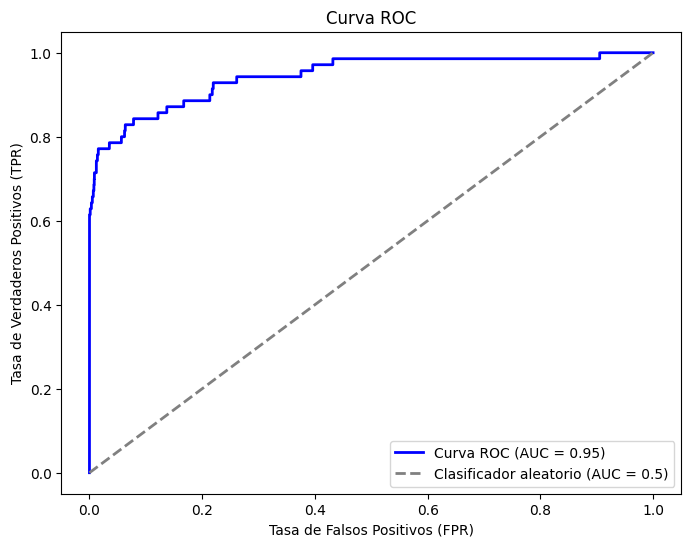

In [356]:
y_score = modelo.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_score)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'Curva ROC (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=2, label='Clasificador aleatorio (AUC = 0.5)')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC')
plt.legend(loc='lower right')
plt.show()

Finalmente, para una comprobación gráfica, decidí utilizar la curva ROC junto con el área bajo la curva (AUC), la cual es de 0.97. Este valor es bastante similar a los resultados obtenidos tanto en la evaluación del modelo como en la validación cruzada (cross-validation).

## Notas del modelo

A pesar de que el modelo mostró un comportamiento aparentemente bueno en términos de métricas de evaluación, como el score de ROC-AUC, se identificó un problema importante durante el proceso de creación de los bins para las variables. Al discretizar las variables en intervalos (bins), algunos valores no quedaban incluidos en ciertos rangos, lo que generaba valores NaN en las categorías correspondientes.Inicialmente, se decidió eliminar los outliers con el objetivo de reducir la aparición de valores NaN. Sin embargo, incluso después de esta limpieza, persistía un número significativo de valores faltantes en las categorías de algunas variables. Esto tuvo un impacto directo en el entrenamiento del modelo, ya que las columnas con valores NaN se eliminaban automáticamente, lo que reducía considerablemente el número de variables disponibles para el modelo. Como consecuencia, el score de ROC-AUC obtenido fue bajo (alrededor de 0.6)
Para abordar este problema, se optó por utilizar la función fillna para imputar los valores faltantes con 0. Esta decisión permitió conservar todas las variables creadas y entrenar el modelo con un conjunto de datos completo. Como resultado, el score de ROC-AUC mejoró significativamente, alcanzando valores mucho más altos. Sin embargo, este enfoque plantea una preocupacion: Al reemplazar los valores NaN con 0, se está asumiendo que las categorías sin observaciones no tienen poder predictivo lo que puede verse como una manipulacion de los datos.

## Coeficientes

In [359]:
betas = list(modelo.coef_[0])
alpha = modelo.intercept_[0]

In [360]:
betas

[np.float64(-1.5240658008986003),
 np.float64(0.2662581023405371),
 np.float64(-0.27750524762030343),
 np.float64(-0.3090647756896959),
 np.float64(-0.40079848547393526),
 np.float64(-0.19862428554407213),
 np.float64(0.3320728151223171),
 np.float64(-0.49706356169011207),
 np.float64(-0.36869256533351846),
 np.float64(0.2416986703920976),
 np.float64(-0.5441201734980722),
 np.float64(0.5586848504851335),
 np.float64(-0.5106029121347572),
 np.float64(-0.011375473724721953),
 np.float64(-0.78116294777139),
 np.float64(-0.56943108963603),
 np.float64(-0.5301282836732533),
 np.float64(-0.5075306277251685),
 np.float64(-0.14327754599647427),
 np.float64(-0.204946324654144),
 np.float64(0.07909855155989634),
 np.float64(0.14170382720386068),
 np.float64(-0.35391066805959065),
 np.float64(-0.4027241119509824),
 np.float64(0.46524901414935627),
 np.float64(-0.6784660049750686),
 np.float64(-0.031299338398468574),
 np.float64(-0.06875336782928457),
 np.float64(0.4400945827567394),
 np.float64(

In [361]:
alpha

np.float64(-1.6604551052298113)

## Score

In [362]:
PDO        = 30  #Puntos para duplicar las probabilidades
base_odds  = 10 #"varianza"
base_score = 300 #"media"

factor = PDO/np.log(2) #Logaritmo de dos porque son dos clases
offset = base_score-factor*np.log(base_odds)
n      = len(varw)

In [363]:
for k,v in enumerate(Xm.columns.tolist()):
    df_modl_sub['P_%s'%v[2:]] = ((df_modl_sub[v]*-betas[k]+alpha/n)*factor+offset/n).astype(int)

In [364]:
df_modl_sub

,amount,variable_01,variable_02,variable_03,variable_04,variable_05,variable_06,variable_07,variable_08,variable_09,variable_10,variable_11,variable_12,variable_13,variable_14,variable_15,variable_16,variable_17,variable_18,variable_19,variable_20,variable_21,variable_22,variable_23,variable_24,variable_25,variable_26,variable_27,variable_28,variable_29,variable_30,variable_31,variable_32,top_5_mean,top_5_std,top_5_sum,top_5_min,top_5_max,top_5_prod,top_2_prod,y,W_amount,W_variable_01,W_variable_02,W_variable_03,W_variable_04,W_variable_05,W_variable_06,W_variable_07,W_variable_08,W_variable_09,W_variable_10,W_variable_11,W_variable_12,W_variable_13,W_variable_14,W_variable_15,W_variable_16,W_variable_17,W_variable_18,W_variable_19,W_variable_20,W_variable_21,W_variable_22,W_variable_23,W_variable_24,W_variable_25,W_variable_26,W_variable_27,W_variable_28,W_variable_29,W_variable_30,W_variable_31,W_variable_32,W_top_5_mean,W_top_5_std,W_top_5_sum,W_top_5_min,W_top_5_max,W_top_5_prod,W_top_2_prod,P_amount,P_variable_01,P_variable_02,P_variable_03,P_variable_04,P_variable_05,P_variable_06,P_variable_07,P_variable_08,P_variable_09,P_variable_10,P_variable_11,P_variable_12,P_variable_13,P_variable_14,P_variable_15,P_variable_16,P_variable_17,P_variable_18,P_variable_19,P_variable_20,P_variable_21,P_variable_22,P_variable_23,P_variable_24,P_variable_25,P_variable_26,P_variable_27,P_variable_28,P_variable_29,P_variable_30,P_variable_31,P_variable_32,P_top_5_mean,P_top_5_std,P_top_5_sum,P_top_5_min,P_top_5_max,P_top_5_prod,P_top_2_prod
1657,"(-0.47, 1.347]","(-6.624, 1.589]","(-3.801, 1.174]","(-0.174, 1.67]","(-0.469, 1.264]","(-0.431, 0.984]","(-2.563, 3.364]","(-1.347, 0.369]","(0.865, 9.403]","(-0.0316, 3.701]","(-0.934, 0.365]","(-4.638, -3.002]","(-13.804, -10.284]","(-7.17, -5.241]","(-0.103, 1.076]","(-11.621, -8.904]","(-1.784, -0.721]","(-9.424, -7.182]","(3.085, 4.214]","(-5.135, -2.913]","(-0.911, 0.744]","(-5.837, -2.417]","(-4.306, -1.723]","(-3.796, -1.006]","(-1.985, 1.286]","(0.334, 1.433]","(-3.259, -1.703]","(0.471, 3.79]","(-2.821, -0.694]","(-0.174, 1.67]","(-7.17, -5.241]","(-6.624, 1.589]","(-3.801, 1.174]","(-16.942, -4.974]","(8.625, 11.22]","(-16.942, -4.974]","(-13.644, -10.883]","(3.541, 5.524]","(16.574, 18.743]","(6.758, 7.802]",1,0.088957,0.116832,0.459015,-0.099816,-0.102995,-0.113924,0.039948,-0.103746,-1.886672,-0.334007,0.530528,-3.409673,-9.589325,-7.797565,0.125409,-9.812468,-0.513087,-7.915348,-5.526233,-5.706651,0.561264,-0.862195,-2.473336,-1.575999,0.169402,0.047068,-1.639066,-0.938690,-0.751581,-0.099816,-7.797565,0.116832,0.459015,-8.788757,-5.905001,-8.788757,-9.994790,-3.819360,0.000000,0.000000,9,1,8,1,1,2,2,0,-26,6,15,85,-208,0,7,-238,-8,-170,-31,-47,1,8,-34,-24,0,4,0,0,17,1,0,1,8,-124,16,-124,-52,-2,3,3
3704,"(-0.47, 1.347]","(-6.624, 1.589]","(-3.801, 1.174]","(-2.018, -0.174]","(-2.202, -0.469]","(-0.431, 0.984]","(-2.563, 3.364]","(-1.347, 0.369]","(0.865, 9.403]","(-3.764, -0.0316]","(0.365, 1.663]","(-6.287, -4.638]","(-13.804, -10.284]","(-9.113999999999999, -7.17]","(-0.103, 1.076]","(-8.904, -6.188]","(-1.784, -0.721]","(-7.182, -4.941]","(3.085, 4.214]","(-7.378, -5.135]","(-2.565, -0.911]","(-2.417, 1.004]","(-6.889, -4.306]","(-1.006, 1.785]","(-5.257, -1.985]","(2.533, 3.632]","(-4.815, -3.259]","(0.471, 3.79]","(-4.947, -2.821]","(-2.018, -0.174]","(-9.113999999999999, -7.17]","(-6.624, 1.589]","(-3.801, 1.174]","(-16.942, -4.974]","(8.625, 11.22]","(-16.942, -4.974]","(-10.883, -8.123]","(3.541, 5.524]","(14.405, 16.574]","(5.714, 6.758]",1,0.088957,0.116832,0.459015,0.017435,0.571162,-0.113924,0.039948,-0.103746,-1.886672,0.397831,0.240301,-8.713856,-9.589325,0.000000,0.125409,-6.839725,-0.513087,-8.038727,-5.526233,-10.100150,-1.031893,0.120501,-2.940340,0.271830,-2.076161,-1.935299,-4.345435,-0.938690,-1.093151,0.017435,0.000000,0.116832,0.459015,-8.788757,-5.905001,-8.788757,-7.030310,-3.819360,-9.669367,-10.148940,9,1,8,3,13,2,2,0,-26,0,8,213,-208,3,7,-165,-8,-173,-31

In [365]:
varp = [v for v in df_modl_sub.columns if v[:2]=='P_']

In [366]:
varp

['P_amount',
 'P_variable_01',
 'P_variable_02',
 'P_variable_03',
 'P_variable_04',
 'P_variable_05',
 'P_variable_06',
 'P_variable_07',
 'P_variable_08',
 'P_variable_09',
 'P_variable_10',
 'P_variable_11',
 'P_variable_12',
 'P_variable_13',
 'P_variable_14',
 'P_variable_15',
 'P_variable_16',
 'P_variable_17',
 'P_variable_18',
 'P_variable_19',
 'P_variable_20',
 'P_variable_21',
 'P_variable_22',
 'P_variable_23',
 'P_variable_24',
 'P_variable_25',
 'P_variable_26',
 'P_variable_27',
 'P_variable_28',
 'P_variable_29',
 'P_variable_30',
 'P_variable_31',
 'P_variable_32',
 'P_top_5_mean',
 'P_top_5_std',
 'P_top_5_sum',
 'P_top_5_min',
 'P_top_5_max',
 'P_top_5_prod',
 'P_top_2_prod']

In [367]:
df_modl_sub['score'] = df_modl_sub[varp].sum(axis=1)

In [368]:
df_modl_sub

,amount,variable_01,variable_02,variable_03,variable_04,variable_05,variable_06,variable_07,variable_08,variable_09,variable_10,variable_11,variable_12,variable_13,variable_14,variable_15,variable_16,variable_17,variable_18,variable_19,variable_20,variable_21,variable_22,variable_23,variable_24,variable_25,variable_26,variable_27,variable_28,variable_29,variable_30,variable_31,variable_32,top_5_mean,top_5_std,top_5_sum,top_5_min,top_5_max,top_5_prod,top_2_prod,y,W_amount,W_variable_01,W_variable_02,W_variable_03,W_variable_04,W_variable_05,W_variable_06,W_variable_07,W_variable_08,W_variable_09,W_variable_10,W_variable_11,W_variable_12,W_variable_13,W_variable_14,W_variable_15,W_variable_16,W_variable_17,W_variable_18,W_variable_19,W_variable_20,W_variable_21,W_variable_22,W_variable_23,W_variable_24,W_variable_25,W_variable_26,W_variable_27,W_variable_28,W_variable_29,W_variable_30,W_variable_31,W_variable_32,W_top_5_mean,W_top_5_std,W_top_5_sum,W_top_5_min,W_top_5_max,W_top_5_prod,W_top_2_prod,P_amount,P_variable_01,P_variable_02,P_variable_03,P_variable_04,P_variable_05,P_variable_06,P_variable_07,P_variable_08,P_variable_09,P_variable_10,P_variable_11,P_variable_12,P_variable_13,P_variable_14,P_variable_15,P_variable_16,P_variable_17,P_variable_18,P_variable_19,P_variable_20,P_variable_21,P_variable_22,P_variable_23,P_variable_24,P_variable_25,P_variable_26,P_variable_27,P_variable_28,P_variable_29,P_variable_30,P_variable_31,P_variable_32,P_top_5_mean,P_top_5_std,P_top_5_sum,P_top_5_min,P_top_5_max,P_top_5_prod,P_top_2_prod,score
1657,"(-0.47, 1.347]","(-6.624, 1.589]","(-3.801, 1.174]","(-0.174, 1.67]","(-0.469, 1.264]","(-0.431, 0.984]","(-2.563, 3.364]","(-1.347, 0.369]","(0.865, 9.403]","(-0.0316, 3.701]","(-0.934, 0.365]","(-4.638, -3.002]","(-13.804, -10.284]","(-7.17, -5.241]","(-0.103, 1.076]","(-11.621, -8.904]","(-1.784, -0.721]","(-9.424, -7.182]","(3.085, 4.214]","(-5.135, -2.913]","(-0.911, 0.744]","(-5.837, -2.417]","(-4.306, -1.723]","(-3.796, -1.006]","(-1.985, 1.286]","(0.334, 1.433]","(-3.259, -1.703]","(0.471, 3.79]","(-2.821, -0.694]","(-0.174, 1.67]","(-7.17, -5.241]","(-6.624, 1.589]","(-3.801, 1.174]","(-16.942, -4.974]","(8.625, 11.22]","(-16.942, -4.974]","(-13.644, -10.883]","(3.541, 5.524]","(16.574, 18.743]","(6.758, 7.802]",1,0.088957,0.116832,0.459015,-0.099816,-0.102995,-0.113924,0.039948,-0.103746,-1.886672,-0.334007,0.530528,-3.409673,-9.589325,-7.797565,0.125409,-9.812468,-0.513087,-7.915348,-5.526233,-5.706651,0.561264,-0.862195,-2.473336,-1.575999,0.169402,0.047068,-1.639066,-0.938690,-0.751581,-0.099816,-7.797565,0.116832,0.459015,-8.788757,-5.905001,-8.788757,-9.994790,-3.819360,0.000000,0.000000,9,1,8,1,1,2,2,0,-26,6,15,85,-208,0,7,-238,-8,-170,-31,-47,1,8,-34,-24,0,4,0,0,17,1,0,1,8,-124,16,-124,-52,-2,3,3,-889
3704,"(-0.47, 1.347]","(-6.624, 1.589]","(-3.801, 1.174]","(-2.018, -0.174]","(-2.202, -0.469]","(-0.431, 0.984]","(-2.563, 3.364]","(-1.347, 0.369]","(0.865, 9.403]","(-3.764, -0.0316]","(0.365, 1.663]","(-6.287, -4.638]","(-13.804, -10.284]","(-9.113999999999999, -7.17]","(-0.103, 1.076]","(-8.904, -6.188]","(-1.784, -0.721]","(-7.182, -4.941]","(3.085, 4.214]","(-7.378, -5.135]","(-2.565, -0.911]","(-2.417, 1.004]","(-6.889, -4.306]","(-1.006, 1.785]","(-5.257, -1.985]","(2.533, 3.632]","(-4.815, -3.259]","(0.471, 3.79]","(-4.947, -2.821]","(-2.018, -0.174]","(-9.113999999999999, -7.17]","(-6.624, 1.589]","(-3.801, 1.174]","(-16.942, -4.974]","(8.625, 11.22]","(-16.942, -4.974]","(-10.883, -8.123]","(3.541, 5.524]","(14.405, 16.574]","(5.714, 6.758]",1,0.088957,0.116832,0.459015,0.017435,0.571162,-0.113924,0.039948,-0.103746,-1.886672,0.397831,0.240301,-8.713856,-9.589325,0.000000,0.125409,-6.839725,-0.513087,-8.038727,-5.526233,-10.100150,-1.031893,0.120501,-2.940340,0.271830,-2.076161,-1.935299,-4.345435,-0.938690,-1.093151,0.017435,0.000000,0.116832,0.459015,-8.788757,-5.905001,-8.788757,-7.030310,-3.819360,-9.669367,-10.148940,9,1,8,3,13,2,2,0,-26,0,8,213,-208,3,7,-165,

<Axes: >

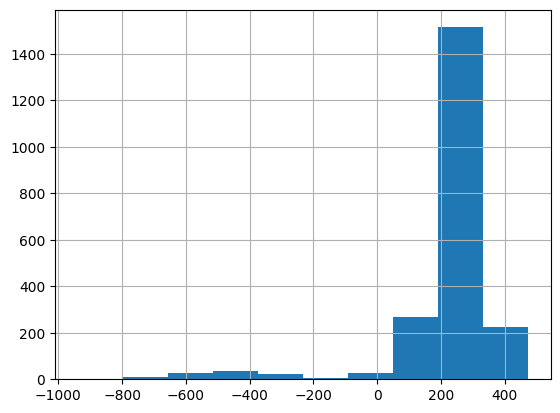

In [369]:
df_modl_sub['score'].hist()

In [370]:
df_modl_sub['score'].describe()

count    2134.000000
mean      224.936739
std       173.425158
min      -940.000000
25%       212.250000
50%       262.000000
75%       303.750000
max       474.000000
Name: score, dtype: float64

In [371]:
for v in Xm.columns.tolist():    
    display(df_modl_sub[['P_'+v[2:],v[2:]]].groupby(v[2:]).max().reset_index())

,amount,P_amount
0,"(-0.47, 1.347]",9
1,"(1.347, 3.147]",-38
2,"(10.346, 12.145]",-157
3,"(3.147, 4.947]",-98
4,"(4.947, 6.746]",-14
5,"(6.746, 8.546]",-66
6,"(8.546, 10.346]",3


,variable_01,P_variable_01
0,"(-14.837, -6.624]",17
1,"(-23.101000000000003, -14.837]",3
2,"(-6.624, 1.589]",1
3,"(1.589, 9.802]",24
4,"(18.015, 26.228]",3


,variable_02,P_variable_02
0,"(-13.751, -8.776]",3
1,"(-3.801, 1.174]",8
2,"(-8.776, -3.801]",-7
3,"(1.174, 6.149]",-20
4,"(6.149, 11.124]",3


,variable_03,P_variable_03
0,"(-0.174, 1.67]",1
1,"(-2.018, -0.174]",3
2,"(-3.874, -2.018]",12
3,"(1.67, 3.513]",13
4,"(3.513, 5.357]",3
5,"(5.357, 7.201]",-37


,variable_04,P_variable_04
0,"(-0.469, 1.264]",1
1,"(-2.202, -0.469]",13
2,"(-3.935, -2.202]",-1
3,"(-5.667, -3.935]",3
4,"(1.264, 2.997]",-6
5,"(2.997, 4.73]",3


...

,top_5_sum,P_top_5_sum
0,"(-16.942, -4.974]",-124
1,"(-4.974, 6.97]",16


,top_5_min,P_top_5_min
0,"(-10.883, -8.123]",-35
1,"(-13.644, -10.883]",-52
2,"(-16.424, -13.644]",3
3,"(-2.603, 0.157]",7
4,"(-5.363, -2.603]",-6
5,"(-8.123, -5.363]",-35
6,"(0.157, 2.918]",16


,top_5_max,P_top_5_max
0,"(-0.425, 1.558]",4
1,"(-2.427, -0.425]",5
2,"(1.558, 3.541]",0
3,"(13.456, 15.439]",3
4,"(3.541, 5.524]",-2
5,"(5.524, 7.507]",-1
6,"(7.507, 9.49]",-1


,top_5_prod,P_top_5_prod
0,"(-0.796, 1.393]",-21
1,"(1.393, 3.562]",4
2,"(10.068, 12.237]",142
3,"(12.237, 14.405]",160
4,"(14.405, 16.574]",172
5,"(16.574, 18.743]",3
6,"(3.562, 5.731]",28
7,"(5.731, 7.899]",58
8,"(7.899, 10.068]",98


,top_2_prod,P_top_2_prod
0,"(-0.55, 0.494]",-14
1,"(-1.6039999999999999, -0.55]",-18
2,"(0.494, 1.538]",-1
3,"(1.538, 2.582]",5
4,"(2.582, 3.626]",11
5,"(3.626, 4.67]",65
6,"(4.67, 5.714]",101
7,"(5.714, 6.758]",126
8,"(6.758, 7.802]",3


## Credit Scoring

In [372]:
df_modl_sub['r_score'] = pd.cut(df_modl_sub['score'],bins=4,include_lowest=True).astype(str)

In [373]:
aux     = df_modl_sub[['r_score','y']].copy()
aux['n']= 1

In [374]:
aux= aux.pivot_table(index='r_score',columns='y',values='n',aggfunc='sum').reset_index().sort_values(by='r_score')

In [375]:
aux = aux.fillna(0)

In [376]:
aux

y,r_score,0,1
0,"(-233.0, 120.5]",48.0,44.0
1,"(-586.5, -233.0]",0.0,73.0
2,"(-941.415, -586.5]",0.0,22.0
3,"(120.5, 474.0]",1924.0,23.0


## Guardado de variables 

In [377]:
aux.reset_index().sort_values(by='r_score',ascending=False).to_excel('SCORE_PHRH_.xlsx') # Scorecard

In [378]:
df_modl_sub[varw].to_csv('Variables_Con_Woe.csv') # Variables con Woe

In [ ]:
#df_sin_woe.to_csv('Variables_Originales.csv') # Variables antes de Woe

In [ ]:
#df_modl_sub.to_csv('Df_Completo_modelo.csv') # Variables con Woe y puntos

## Guardado de Modelo y objetos

In [379]:
with open ('Modelo_P1_Credit_Scoring.pkl', 'wb') as archivo:
    pck.dump(modelo,archivo)

In [380]:
jlb.dump(sc, "standar_scaler.pkl")

['standar_scaler.pkl']

## Evaluacion 

In [381]:
df_val = X_test.copy() # Set de validacion

In [382]:
df_val['y'] = y_test

In [427]:
df_val['y'].value_counts()

y
0    84518
1       70
Name: count, dtype: int64

In [428]:
Xv_sam = X_test.sample(10)

In [429]:
Xv_sam

,W_amount,W_variable_01,W_variable_02,W_variable_03,W_variable_04,W_variable_05,W_variable_06,W_variable_07,W_variable_08,W_variable_09,W_variable_10,W_variable_11,W_variable_12,W_variable_13,W_variable_14,W_variable_15,W_variable_16,W_variable_17,W_variable_18,W_variable_19,W_variable_20,W_variable_21,W_variable_22,W_variable_23,W_variable_24,W_variable_25,W_variable_26,W_variable_27,W_variable_28,W_variable_29,W_variable_30,W_variable_31,W_variable_32,W_top_5_mean,W_top_5_std,W_top_5_sum,W_top_5_min,W_top_5_max,W_top_5_prod,W_top_2_prod
34908,0.088957,0.116832,0.459015,0.017435,-0.102995,1.203103,0.039948,-0.103746,0.368185,0.397831,0.240301,0.477459,1.233463,-1.179976,0.125409,1.923807,0.351705,1.503063,1.006200,-0.174541,1.006855,0.120501,0.590449,2.426410,-0.425417,3.331725,-1.639066,1.078105,0.364384,0.017435,-1.179976,0.116832,0.459015,0.913118,1.714993,0.913118,2.336727,0.583299,1.398287,0.364888
57114,0.088957,0.116832,0.459015,-0.099816,0.571162,-0.113924,0.039948,0.092919,0.368185,0.397831,0.530528,0.477459,0.392699,1.074069,0.032590,0.000000,-0.046717,-2.676369,1.006200,-0.174541,1.006855,0.120501,0.018650,-1.575999,0.169402,1.610926,-0.059556,-0.938690,0.364384,-0.099816,1.074069,0.116832,0.459015,0.913118,-0.111594,0.913118,0.772383,-2.054289,1.398287,-0.653948
14280,0.088957,-1.838624,0.459015,0.795329,-0.273814,-0.113924,0.039948,-0.103746,-1.886672,0.397831,-1.129619,0.255508,1.233463,1.074069,0.092943,1.923807,-0.046717,1.503063,-0.015666,1.203076,0.561264,0.120501,0.590449,0.271830,0.169402,1.610926,1.466913,1.078105,0.364384,0.795329,1.074069,-1.838624,0.459015,0.913118,1.714993,0.913118,2.336727,0.583299,1.398287,1.466470
6042,0.088957,0.116832,0.459015,0.017435,-0.102995,-0.113924,0.039948,-0.103746,0.368185,0.397831,0.530528,0.477459,0.392699,1.074069,0.092943,1.923807,-0.046717,1.503063,1.006200,-0.174541,-1.031893,0.120501,0.590449,0.271830,0.169402,0.047068,1.576933,-0.938690,0.364384,0.017435,1.074069,0.116832,0.459015,0.913118,1.714993,0.913118,2.336727,1.659110,1.398287,1.466470
57605,0.088957,0.116832,0.459015,-0.099816,-0.102995,-0.113924,0.039948,-0.103746,0.368185,0.397831,0.530528,0.477459,1.233463,1.074069,0.125409,1.923807,-0.046717,1.503063,1.212020,1.203076,1.006855,0.120501,0.590449,0.271830,0.169402,0.047068,1.466913,1.078105,0.364384,-0.099816,1.074069,0.116832,0.459015,0.913118,1.714993,0.913118,2.336727,0.583299,1.398287,1.466470
11103,0.088957,0.116832,-0.903909,0.017435,-0.273814,-0.113924,0.039948,-0.103746,0.368185,0.397831,-0.558913,0.477459,1.233463,0.226733,0.125409,1.923807,-0.513087,-0.099117,1.212020,1.092019,0.561264,0.120501,0.018650,0.271830,0.169402,-2.116540,1.466913,-0.938690,0.364384,0.017435,0.226733,0.116832,-0.903909,0.913118,-0.111594,0.913118,0.772383,-2.054289,-0.081064,0.364888
20239,0.088957,0.116832,0.459015,-0.099816,-0.102995,-0.277382,0.039948,-0.103746,0.368185,0.397831,0.530528,0.477459,1.233463,1.074069,0.092943,1.923807,0.351705,1.503063,1.212020,1.203076,0.561264,0.120501,0.590449,0.271830,0.169402,0.047068,1.466913,1.078105,0.364384,-0.099816,1.074069,0.116832,0.459015,0.913118,1.714993,0.913118,2.336727,1.659110,1.398287,1.774621
61790,-0.269233,0.116832,-1.992430,0.795329,0.571162,1.203103,0.039948,0.092919,0.368185,0.000000,0.240301,0.477459,0.392699,1.074069,0.125409,1.923807,-0.046717,1.503063,1.212020,-0.174541,0.561264,0.120501,-1.249346,2.426410,0.000000,1.610926,-0.059556,-0.938690,-0.751581,0.795329,1.074069,0.116832,-1.992430,0.913118,1.714993,0.913118,2.336727,0.583299,1.398287,1.774621
58147,0.088957,0.116832,0.459015,0.017435,-0.102995,1.203103,0.039948,0.092919,0.368185,-0.334007,0.240301,-0.765471,1.233463,0.226733,0.125409,1.923807,0.351705,-0.099117,1.006200,1.203076,0.561264,0.120501,0.590449,2.426410,-0.425417,3.331725,-1.639066,1.078105,0.364384,0.017435,0.226733,0.116832,0.459015,0.913118,1.714993,0.913118,2.336727,0.583299,1.398287,1.774621
61320,0.088957,0.116832,0.459015,-0.099816,-0.102995,1.203103,0.039948,-0.103746,0.36818

In [404]:
with open('Modelo_P1_Credit_Scoring.pkl', 'rb') as archivo:
    Model = pck.load(archivo)

In [430]:
Predicciones = Model.predict(Xv_sam)

In [431]:
Predicciones

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [432]:
index_sam = Xv_sam.index

In [433]:
index_sam

Index([34908, 57114, 14280, 6042, 57605, 11103, 20239, 61790, 58147, 61320], dtype='int64')

In [434]:
df_val.loc[index_sam, 'y'] # Podemos ver que el modelo detecto correctamente los caso de fraude del test de validacion

34908    0
57114    0
14280    0
6042     0
57605    0
11103    0
20239    0
61790    0
58147    0
61320    0
Name: y, dtype: int64

In [436]:
df_val.iloc[index_sam]

,W_amount,W_variable_01,W_variable_02,W_variable_03,W_variable_04,W_variable_05,W_variable_06,W_variable_07,W_variable_08,W_variable_09,W_variable_10,W_variable_11,W_variable_12,W_variable_13,W_variable_14,W_variable_15,W_variable_16,W_variable_17,W_variable_18,W_variable_19,W_variable_20,W_variable_21,W_variable_22,W_variable_23,W_variable_24,W_variable_25,W_variable_26,W_variable_27,W_variable_28,W_variable_29,W_variable_30,W_variable_31,W_variable_32,W_top_5_mean,W_top_5_std,W_top_5_sum,W_top_5_min,W_top_5_max,W_top_5_prod,W_top_2_prod,y
34908,0.088957,0.116832,0.459015,0.017435,-0.102995,1.203103,0.039948,-0.103746,0.368185,0.397831,0.240301,0.477459,1.233463,-1.179976,0.125409,1.923807,0.351705,1.503063,1.006200,-0.174541,1.006855,0.120501,0.590449,2.426410,-0.425417,3.331725,-1.639066,1.078105,0.364384,0.017435,-1.179976,0.116832,0.459015,0.913118,1.714993,0.913118,2.336727,0.583299,1.398287,0.364888,0
57114,0.088957,0.116832,0.459015,-0.099816,0.571162,-0.113924,0.039948,0.092919,0.368185,0.397831,0.530528,0.477459,0.392699,1.074069,0.032590,0.000000,-0.046717,-2.676369,1.006200,-0.174541,1.006855,0.120501,0.018650,-1.575999,0.169402,1.610926,-0.059556,-0.938690,0.364384,-0.099816,1.074069,0.116832,0.459015,0.913118,-0.111594,0.913118,0.772383,-2.054289,1.398287,-0.653948,0
14280,0.088957,-1.838624,0.459015,0.795329,-0.273814,-0.113924,0.039948,-0.103746,-1.886672,0.397831,-1.129619,0.255508,1.233463,1.074069,0.092943,1.923807,-0.046717,1.503063,-0.015666,1.203076,0.561264,0.120501,0.590449,0.271830,0.169402,1.610926,1.466913,1.078105,0.364384,0.795329,1.074069,-1.838624,0.459015,0.913118,1.714993,0.913118,2.336727,0.583299,1.398287,1.466470,0
6042,0.088957,0.116832,0.459015,0.017435,-0.102995,-0.113924,0.039948,-0.103746,0.368185,0.397831,0.530528,0.477459,0.392699,1.074069,0.092943,1.923807,-0.046717,1.503063,1.006200,-0.174541,-1.031893,0.120501,0.590449,0.271830,0.169402,0.047068,1.576933,-0.938690,0.364384,0.017435,1.074069,0.116832,0.459015,0.913118,1.714993,0.913118,2.336727,1.659110,1.398287,1.466470,0
57605,0.088957,0.116832,0.459015,-0.099816,-0.102995,-0.113924,0.039948,-0.103746,0.368185,0.397831,0.530528,0.477459,1.233463,1.074069,0.125409,1.923807,-0.046717,1.503063,1.212020,1.203076,1.006855,0.120501,0.590449,0.271830,0.169402,0.047068,1.466913,1.078105,0.364384,-0.099816,1.074069,0.116832,0.459015,0.913118,1.714993,0.913118,2.336727,0.583299,1.398287,1.466470,0
11103,0.088957,0.116832,-0.903909,0.017435,-0.273814,-0.113924,0.039948,-0.103746,0.368185,0.397831,-0.558913,0.477459,1.233463,0.226733,0.125409,1.923807,-0.513087,-0.099117,1.212020,1.092019,0.561264,0.120501,0.018650,0.271830,0.169402,-2.116540,1.466913,-0.938690,0.364384,0.017435,0.226733,0.116832,-0.903909,0.913118,-0.111594,0.913118,0.772383,-2.054289,-0.081064,0.364888,0
20239,0.088957,0.116832,0.459015,-0.099816,-0.102995,-0.277382,0.039948,-0.103746,0.368185,0.397831,0.530528,0.477459,1.233463,1.074069,0.092943,1.923807,0.351705,1.503063,1.212020,1.203076,0.561264,0.120501,0.590449,0.271830,0.169402,0.047068,1.466913,1.078105,0.364384,-0.099816,1.074069,0.116832,0.459015,0.913118,1.714993,0.913118,2.336727,1.659110,1.398287,1.774621,0
61790,-0.269233,0.116832,-1.992430,0.795329,0.571162,1.203103,0.039948,0.092919,0.368185,0.000000,0.240301,0.477459,0.392699,1.074069,0.125409,1.923807,-0.046717,1.503063,1.212020,-0.174541,0.561264,0.120501,-1.249346,2.426410,0.000000,1.610926,-0.059556,-0.938690,-0.751581,0.795329,1.074069,0.116832,-1.992430,0.913118,1.714993,0.913118,2.336727,0.583299,1.398287,1.774621,0
58147,0.088957,0.116832,0.459015,0.017435,-0.102995,1.203103,0.039948,0.092919,0.368185,-0.334007,0.240301,-0.765471,1.233463,0.226733,0.125409,1.923807,0.351705,-0.099117,1.006200,1.203076,0.561264,0.120501,0.590449,2.426410,-0.425417,3.331725,-1.639066,1.078105,0.364384,0.017435,0.226733,0.116832,0.459015,0.913118,1.714993,0.913118,2.336727,0.583299,1.398287,1.774621,0
61320,0.088957,0.116832,0.459015,-0.099816,-0.102995,1.203103,0.0399

In [437]:
aux

y,r_score,0,1
0,"(-233.0, 120.5]",48.0,44.0
1,"(-586.5, -233.0]",0.0,73.0
2,"(-941.415, -586.5]",0.0,22.0
3,"(120.5, 474.0]",1924.0,23.0


Podemos ver que en los primeros dos bines (las que tienen el score mas bajo) no hay valores que correspondan a la clase 0, es decir que practicamente es fraude, para el siguiente bin las clases son muy similares en numero, por lo que hay una probabilidad del 50% aproximadamente de que sea fraude, y para la ultima clase la probabilidad de fraude es practicamente del 1% solamente.